# 🌾 Global Agricultural Production & Analytical Mapping (FAOSTAT Analysis)
**An End-to-End Data Science Project featuring EDA, Geospatial Visualization, and Unsupervised Machine Learning**

---

### 📌 Introduction & Project Scope
The agricultural sector is a fundamental pillar of the global economy, food security, and sustainable development. This project presents a comprehensive data analysis based on the **FAOSTAT** database provided by the Food and Agriculture Organization (FAO) of the United Nations.

**Core Objectives:**
* **Data Cleaning & Preprocessing:** Resolving duplicate records, filtering out geographical aggregates to isolate standalone countries, standardizing measurement units (converting 100g/ha to t/ha), and handling missing values.
* **Exploratory Data Analysis (EDA):** Tracking long-term historical trends in production, harvested area, and yield for key strategic crops (Olives, Wheat, Maize), with a dedicated focus on comparing **Greece vs. the European Union**.
* **Geospatial Analysis:** Leveraging `GeoPandas` to build global interactive choropleth maps illustrating production distribution.
* **Unsupervised Machine Learning:** 
  * Applying **K-Means Clustering** to segment global rural economies into distinct "Agricultural Profiles".
  * Utilizing **Feature Engineering (Log Transformations)** to decouple technological productivity from total country size.
  * Reducing dimensionality via **PCA (Principal Component Analysis)** for clear 2D cluster visualization.

---

### 🛠️ Tech Stack
* **Language:** Python 3
* **Data Processing:** `pandas`, `numpy`
* **Visualization:** `matplotlib`, `seaborn`
* **Geospatial:** `geopandas`
* **Machine Learning:** `scikit-learn` (`StandardScaler`, `KMeans`, `PCA`)

### 1. Data Ingestion & Environment Setup
This step dynamically handles dataset loading. It first attempts to load files directly from the Kaggle input directory. If executed locally or in Google Colab, it uses `kagglehub` to automatically fetch the dataset files.

In [1]:
import os
import numpy as np
import pandas as pd
import kagglehub

# Try loading from Kaggle environment first, otherwise download via kagglehub
try:
   
    base_path = '/kaggle/input/datasets/vijayveersingh/faostat-crops-and-livestock-data/'
    
    df_all_data = pd.read_csv(f'{base_path}Production_Crops_Livestock_E_All_Data.csv')
    df_all_data_noflag = pd.read_csv(f'{base_path}Production_Crops_Livestock_E_All_Data_NOFLAG.csv')
    df_area_codes = pd.read_csv(f'{base_path}Production_Crops_Livestock_E_AreaCodes.csv')
    df_elements = pd.read_csv(f'{base_path}Production_Crops_Livestock_E_Elements.csv')
    df_flags = pd.read_csv(f'{base_path}Production_Crops_Livestock_E_Flags.csv')
    df_item_codes = pd.read_csv(f'{base_path}Production_Crops_Livestock_E_ItemCodes.csv')
    
    print("Loaded dataset directly from Kaggle environment.")

except Exception as e:
   
    print("Running outside Kaggle environment. Downloading dataset via kagglehub...")
    
    path = kagglehub.dataset_download("vijayveersingh/faostat-crops-and-livestock-data")
    
    df_all_data = pd.read_csv(os.path.join(path, 'Production_Crops_Livestock_E_All_Data.csv'), encoding='latin-1')
    df_all_data_noflag = pd.read_csv(os.path.join(path, 'Production_Crops_Livestock_E_All_Data_NOFLAG.csv'), encoding='latin-1')
    df_area_codes = pd.read_csv(os.path.join(path, 'Production_Crops_Livestock_E_AreaCodes.csv'), encoding='latin-1')
    df_elements = pd.read_csv(os.path.join(path, 'Production_Crops_Livestock_E_Elements.csv'), encoding='latin-1')
    df_flags = pd.read_csv(os.path.join(path, 'Production_Crops_Livestock_E_Flags.csv'), encoding='latin-1')
    df_item_codes = pd.read_csv(os.path.join(path, 'Production_Crops_Livestock_E_ItemCodes.csv'), encoding='latin-1')


/tmp/ipykernel_16/622025503.py:11: DtypeWarning: Columns (11,14,17,20,23,26,29,32,35,38,41,44,47,50,53,56,59,62,65,68,71,74,77,80,83,86,89,92,95,98,101,104,107,110,113,116,119,122,125,128,131,134,137,140,143,146,149,152,155,158,161,164,167,170,173,176,179,182,185,188,191,194,197) have mixed types. Specify dtype option on import or set low_memory=False.
  df_all_data = pd.read_csv(f'{base_path}Production_Crops_Livestock_E_All_Data.csv')


Loaded dataset directly from Kaggle environment.


### 2. Initial Dataset Inspection & Structural Overview
In this step, we perform an initial inspection across all imported FAOSTAT tables (`df_all_data`, `df_all_data_noflag`, `df_area_codes`, `df_elements`, `df_flags`, and `df_item_codes`). 

**Key Technical Observations:**
* **Dataset Dimensions:** The main production dataset contains **79,711 rows** and **198 columns** in its raw flagged version (and **72 columns** in the unflagged version).
* **Temporal Scope:** The dataset covers annual agricultural metrics spanning over six decades, from **1961 through 2023** (`Y1961` to `Y2023`).
* **Metadata Relational Tables:** 
  * `df_area_codes`: Maps 245 area entities (both individual countries and regional aggregates).
  * `df_elements`: Defines 22 tracked agricultural metrics (e.g., *Area Harvested*, *Yield*, *Production*).
  * `df_flags`: Contains status metadata (e.g., `A` for official figures, `E` for estimated values).
  * `df_item_codes`: Catalogs 307 agricultural commodities and livestock products.

In [2]:
print('All_Data')
print('\n',df_all_data.head())
print('\n',df_all_data.info())
print('\n',df_all_data.describe())

print('\n'+'All_Data_NoFlag')
print('\n',df_all_data_noflag.head())
print('\n',df_all_data_noflag.info())
print('\n',df_all_data_noflag.describe())

print('\n'+'Area_Codes')
print('\n',df_area_codes.head())
print('\n',df_area_codes.info())
print('\n',df_area_codes.describe())

print('\n'+'Elements')
print('\n',df_elements.head())
print('\n',df_elements.info())
print('\n',df_elements.describe())

print('\n'+'Flags')
print('\n',df_flags.head())
print('\n',df_flags.info())
print('\n',df_flags.describe())

print('\n'+'Item_Codes')
print('\n',df_item_codes.head())
print('\n',df_item_codes.info())
print('\n',df_item_codes.describe())


All_Data

    Area Code Area Code (M49)         Area  Item Code Item Code (CPC)  \
0          2            '004  Afghanistan        221          '01371   
1          2            '004  Afghanistan        221          '01371   
2          2            '004  Afghanistan        221          '01371   
3          2            '004  Afghanistan        711          '01654   
4          2            '004  Afghanistan        711          '01654   

                                                Item  Element Code  \
0                                  Almonds, in shell          5312   
1                                  Almonds, in shell          5412   
2                                  Almonds, in shell          5510   
3  Anise, badian, coriander, cumin, caraway, fenn...          5312   
4  Anise, badian, coriander, cumin, caraway, fenn...          5412   

          Element   Unit  Y1961  ... Y2020N    Y2021  Y2021F Y2021N    Y2022  \
0  Area harvested     ha    0.0  ...    NaN  36862.0   

### 3. Inspection of Commodity Measurement Units
Before proceeding with data transformation, we extract and inspect all unique combinations of agricultural items (`Item`), metrics (`Element`), and their corresponding units of measurement (`Unit`). 

**Key Technical Objectives:**
* Identify unit discrepancies across commodities (e.g., area in hectares `ha`, production in tonnes `t`, and yield in `kg/ha` or `100g/ha`).
* Export a clean mapping table (`measurement_units.csv`) to serve as a reference for standardized unit conversions during the data cleaning pipeline.

In [3]:
df_item_element_unit = (
    df_all_data_noflag[['Item', 'Element', 'Unit']]
    .drop_duplicates()
    .sort_values(['Item', 'Element'])
)

df_item_element_unit = df_item_element_unit.reset_index(drop=True)

print(df_item_element_unit)

df_item_element_unit.to_csv('measurement_units.csv', index=False)

                          Item         Element   Unit
0      Abaca, manila hemp, raw  Area harvested     ha
1      Abaca, manila hemp, raw      Production      t
2      Abaca, manila hemp, raw           Yield  kg/ha
3    Agave fibres, raw, n.e.c.  Area harvested     ha
4    Agave fibres, raw, n.e.c.      Production      t
..                         ...             ...    ...
725                       Yams           Yield  kg/ha
726                     Yautia  Area harvested     ha
727                     Yautia      Production      t
728                     Yautia           Yield  kg/ha
729                    Yoghurt      Production      t

[730 rows x 3 columns]


### 4. Resolving Duplicate Measurement Units (Egg Production Data)
In the raw dataset, certain livestock commodities—specifically egg production metrics—contain duplicate records resulting from conflicting measurement units (e.g., volume measured in both thousands of items `1000 No` / `No/An` and metric tonnes `t` / `100 mg/An`).

**Key Technical Actions:**
* **Unit Standardization:** Filter out duplicate entries using secondary units (`1000 No` and `No/An`) to enforce a single, consistent metric system based on mass (`t` for Production and `100 mg/An` for Yield).
* **Record Integrity:** Reduced total dataset rows from **79,711** to **79,098**, successfully removing 613 redundant measurement entries.
* **Verification:** Grouped egg commodities by `Item` and `Element` to verify that each metric now retains exactly one unique unit.

In [4]:
# Cleaning from items with double measurement units

print("Lines before cleaning:", len(df_all_data_noflag))

condition_eggs_prod = (
    df_all_data_noflag['Item'].isin(['Hen eggs in shell, fresh', 'Eggs from other birds in shell, fresh, n.e.c.']) & 
    (df_all_data_noflag['Unit'] == '1000 No')
)

condition_eggs_yield = (
    df_all_data_noflag['Item'].isin(['Hen eggs in shell, fresh', 'Eggs from other birds in shell, fresh, n.e.c.']) & 
    (df_all_data_noflag['Unit'] == 'No/An')
)


df_all_data_noflag = df_all_data_noflag[~(condition_eggs_prod | condition_eggs_yield)].copy()


print("Lines after cleaning:", len(df_all_data_noflag))



check_eggs = df_all_data_noflag[
    df_all_data_noflag['Item'].isin(['Eggs Primary', 'Hen eggs in shell, fresh', 'Eggs from other birds in shell, fresh, n.e.c.'])
].groupby(['Item', 'Element'])['Unit'].unique()

print("\nMeasurement Units for Eggs:")
print(check_eggs)


Lines before cleaning: 79711
Lines after cleaning: 79098

Measurement Units for Eggs:
Item                                           Element   
Eggs Primary                                   Laying          [1000 An]
                                               Production            [t]
                                               Yield         [100 mg/An]
Eggs from other birds in shell, fresh, n.e.c.  Laying          [1000 An]
                                               Production            [t]
                                               Yield         [100 mg/An]
Hen eggs in shell, fresh                       Laying          [1000 An]
                                               Production            [t]
                                               Yield         [100 mg/An]
Name: Unit, dtype: object


### 5. Reshaping Data Structure (Melting & Pivoting)
To prepare the dataset for exploratory analysis and machine learning, we transform it from a wide format (where each year is a separate column) into a clean, tidy long format.

**Key Technical Steps:**
* **Unpivoting (Melting):** Transformed year columns (`Y1961`–`Y2023`) into a single `Year` column, standardizing year identifiers as integer data types.
* **Missing Value Handling:** Dropped empty `NaN` value records to optimize memory efficiency and eliminate non-informative data points.
* **Metric Restructuring (Pivoting):** Pivoted the `Element` attribute so that metrics like *Area harvested*, *Yield*, and *Production* become explicit, separate feature columns.
* **Output Dimensions:** The final structured dataset expands to **1,734,061 tidy rows** across **15 features**, containing both standalone countries and regional aggregates (e.g., *World*, *European Union (27)*).

In [5]:
year_columns = [col for col in df_all_data_noflag.columns if col.startswith('Y')] # Select Year columns (Y1961 to Y2023)

id_vars = ['Area Code', 'Area Code (M49)', 'Area', 'Item Code', 'Item Code (CPC)', 'Item', 'Element Code', 'Element', 'Unit']

df_melted = pd.melt(
    df_all_data_noflag,
    id_vars=id_vars,
    value_vars=year_columns,
    var_name='Year',
    value_name='Value'
)

df_melted['Year'] = df_melted['Year'].str.replace('Y', '').astype(int) # Clean up the year name (e.g. from 'Y1961' to the integer 1961)


# Removing rows with NaN in Value (since they offer no information)
df_clean = df_melted.dropna(subset=['Value']).copy()



# Pivot (Converting 'Element' from rows to separate columns)
# Create columns for Area harvested, Yield, Production 
df_final = df_clean.pivot_table(
    index=['Area Code', 'Area Code (M49)', 'Area', 'Item Code', 'Item Code (CPC)', 'Item', 'Year'],
    columns='Element',
    values='Value'
).reset_index()

df_final.columns.name = None

print("Final DataFrame columns:\n", df_final.columns)
print("Shape of final DataFrame:", df_final.shape)

print(df_final['Area'].unique())

Final DataFrame columns:
 Index(['Area Code', 'Area Code (M49)', 'Area', 'Item Code', 'Item Code (CPC)',
       'Item', 'Year', 'Area harvested', 'Laying', 'Milk Animals',
       'Producing Animals/Slaughtered', 'Production', 'Stocks', 'Yield',
       'Yield/Carcass Weight'],
      dtype='object')
Shape of final DataFrame: (1734061, 15)
['Armenia' 'Afghanistan' 'Albania' 'Algeria' 'Angola'
 'Antigua and Barbuda' 'Argentina' 'Australia' 'Austria' 'Bahamas'
 'Bahrain' 'Barbados' 'Belgium-Luxembourg' 'Bangladesh' 'Bhutan'
 'Bolivia (Plurinational State of)' 'Botswana' 'Brazil' 'Belize'
 'Solomon Islands' 'Brunei Darussalam' 'Bulgaria' 'Myanmar' 'Burundi'
 'Cameroon' 'Canada' 'Cabo Verde' 'Central African Republic' 'Sri Lanka'
 'Chad' 'Chile' 'China, mainland' 'Colombia' 'Comoros' 'Congo'
 'Cook Islands' 'Costa Rica' 'Cuba' 'Cyprus' 'Czechoslovakia' 'Azerbaijan'
 'Benin' 'Denmark' 'Dominica' 'Dominican Republic' 'Belarus' 'Ecuador'
 'Egypt' 'El Salvador' 'Equatorial Guinea' 'Ethiopia PDR' 

### 6. Isolation of Area Metadata & Identification of Aggregate Codes
To prepare for isolating individual countries from continental, regional, and economic aggregates (e.g., *European Union*, *World*, *Least Developed Countries*), we extract a clean reference table of all unique geographic entities.

**Key Technical Observations & Rule Identification:**
* **Unique Extraction:** Deduplicated the `Area`, `Area Code`, and `Area Code (M49)` columns to catalog all 245 geographic entities present in the dataset.
* **Code Pattern Discovery:** Inspection of the exported metadata (`df_code.csv`) revealed a strict FAOSTAT coding rule: **`Area Code >= 5000` exclusively identifies regional/global aggregates**, whereas values below 5000 correspond to standalone countries.
* **Metadata Export:** Saved the mapping table to `df_code.csv` to drive the downstream filtering pipeline for EDA and Machine Learning.

In [6]:
df_codes = df_final[['Area', 'Area Code', 'Area Code (M49)']].drop_duplicates(subset=['Area']).reset_index(drop=True)

print(df_codes)

df_codes.to_csv('df_code.csv', index=False)
print("File 'df_code.csv' was created successfully!")

                                        Area  Area Code Area Code (M49)
0                                    Armenia          1            '051
1                                Afghanistan          2            '004
2                                    Albania          3            '008
3                                    Algeria          4            '012
4                                     Angola          7            '024
..                                       ...        ...             ...
240                Least Developed Countries       5801            '199
241         Land Locked Developing Countries       5802            '432
242           Small Island Developing States       5803            '722
243        Low Income Food Deficit Countries       5815            '901
244  Net Food Importing Developing Countries       5817            '902

[245 rows x 3 columns]
File 'df_code.csv' was created successfully!


### 7. Entity Disambiguation: Handling China Regional Overlaps
During the geographical code review, a critical exception to the FAOSTAT coding convention was identified regarding **China**. Unlike standard regional aggregates that use codes $\ge 5000$, the general entry `China` is assigned `Area Code 351` despite acting as a composite aggregate.

**Key Analytical Insights:**
* **Aggregate Breakdown:** The general entity `China` (`Area Code 351`) represents an aggregate that sums values from `China, mainland` (41), `China, Hong Kong SAR` (96), and `China, Macao SAR` (128).
* **Double-Counting Prevention:** To avoid artificial inflation in subsequent country-level aggregations and Machine Learning models, individual sub-regions (or the composite total) must be explicitly filtered out based on the analytical scope.
* **Code Mapping:** Mapped exact `Area Code` values for all 5 China-related entities in the dataset to handle conditional filtering accurately.

In [7]:
china_df = df_final[df_final['Area'].str.contains('China', na=False)]

china_dict = dict(zip(china_df['Area'], china_df['Area Code']))

for area, area_code in china_dict.items():
    print(f"Area: {area} -> Area Code: {area_code}")

Area: China, mainland -> Area Code: 41
Area: China, Hong Kong SAR -> Area Code: 96
Area: China, Macao SAR -> Area Code: 128
Area: China, Taiwan Province of -> Area Code: 214
Area: China -> Area Code: 351


### 8. Partitioning Dataset into Standalone Countries vs. Regional Aggregates
Using the established criteria—filtering entities with `Area Code >= 5000` alongside the explicit exception for `China` (`Area Code 351`)—we isolate individual nation-states from macro-regional and economic groupings.

**Key Technical Actions:**
* **Boolean Masking:** Created an `is_aggregate` condition to segregate composite areas (e.g., *World*, *European Union (27)*, *Africa*, *China*) from standalone territories.
* **Dataset Splitting:** 
  * `df_countries`: Retains **1,279,294 records** representing **210 unique standalone countries**.
  * `df_aggregates`: Isolates **454,767 records** representing **35 unique regional aggregates**.
* **Data Integrity:** Eliminates double-counting risks, ensuring that subsequent country-level Exploratory Data Analysis (EDA) and Machine Learning models operate purely on distinct national entities.

In [8]:
# Separation between Countries and Aggregates based on Area Code
is_aggregate = ((df_final['Area Code'] >= 5000) | (df_final['Area'] == 'China'))

df_countries = df_final[~is_aggregate].copy()
df_aggregates = df_final[is_aggregate].copy()

print("📊 Separation Results:")
print(f"• Countries (df_countries): {len(df_countries):,} records ({df_countries['Area'].nunique()} unique countries)")
print(f"• Aggregates (df_aggregates): {len(df_aggregates):,} records ({df_aggregates['Area'].nunique()} unique regions)")

📊 Separation Results:
• Countries (df_countries): 1,279,294 records (210 unique countries)
• Aggregates (df_aggregates): 454,767 records (35 unique regions)


### 9. Exporting Cleaned Country-Level Dataset
With the preprocessing pipeline complete and macro-aggregates successfully filtered out, we persist the cleaned country-level DataFrame to a CSV file.

**Key Technical Actions:**
* **Data Persistence:** Saved `df_countries` to `df_countries.csv` with index exclusion (`index=False`).
* **Downstream Integration:** Serves as the standardized, primary dataset for all subsequent Exploratory Data Analysis (EDA), geospatial mapping, and unsupervised machine learning tasks.

In [9]:
df_countries.to_csv('df_countries.csv', index=False)
print("File 'df_countries.csv' was created successfully!")

File 'df_countries.csv' was created successfully!


### 10. Segmented Summary Statistics by Agricultural Category
To resolve metric heterogeneity and avoid mathematically invalid aggregations (such as mixing crop harvested area in hectares with livestock slaughter counts in head), we segment summary statistics strictly across three domain categories:

1. **Crops & Plant Production:** Evaluated via `Area harvested` (ha), `Production` (tonnes), and `Yield` (kg/ha).
2. **Meat Production (Large Livestock):** Evaluated via `Producing Animals/Slaughtered` (head) and `Production` (tonnes).
3. **Dairy & Milk Production:** Evaluated via `Milk Animals` (head) and `Production` (tonnes).

This domain isolation guarantees unit consistency and establishes a robust baseline for upcoming Exploratory Data Analysis (EDA).

In [10]:
import pandas as pd

# 1. Crops & Plant Production (Records having 'Area harvested')
crops_df = df_countries[df_countries['Area harvested'].notna()]

# 2. Meat Production - Large Livestock (Cattle, Pigs, Sheep, Goats)
large_animals_meat = [
    'Meat of cattle with the bone, fresh or chilled',
    'Meat of buffalo, fresh or chilled',
    'Meat of pig with the bone, fresh or chilled',
    'Meat of sheep, fresh or chilled',
    'Meat of goat, fresh or chilled'
]
meat_df = df_countries[df_countries['Item'].isin(large_animals_meat)]

# 3. Dairy & Milk Production (Items containing 'Milk')
milk_types = [
    'Raw milk of cattle', 'Raw milk of buffalo', 
    'Raw milk of camel', 'Raw milk of goats', 'Raw milk of sheep'
]
milk_df = df_countries[df_countries['Item'].isin(milk_types)]

# Display Summary Statistics
pd.set_option('display.float_format', lambda x: '%.2f' % x)

print("🌾 --- 1. CROPS & PLANT PRODUCTION ---")
print(crops_df[['Area harvested', 'Production', 'Yield']].describe())

print("\n🥩 --- 2. MEAT PRODUCTION (LARGE LIVESTOCK) ---")
print(meat_df[['Producing Animals/Slaughtered', 'Production']].describe())

print("\n🥛 --- 3. DAIRY & MILK PRODUCTION ---")
print(milk_df[['Milk Animals', 'Production']].describe())

🌾 --- 1. CROPS & PLANT PRODUCTION ---
       Area harvested   Production       Yield
count       590935.00    590552.00   571391.00
mean        273851.33   1195268.48    10563.25
std        2412117.02  11826779.94    87146.14
min              0.00         0.00        0.00
25%            600.00      2190.35     1196.60
50%           5093.00     21149.50     4651.60
75%          40000.00    166526.25    11647.35
max      125150000.00 782585836.00 24499500.00

🥩 --- 2. MEAT PRODUCTION (LARGE LIVESTOCK) ---
       Producing Animals/Slaughtered  Production
count                       44580.00    44505.00
mean                      2765141.70   196686.46
std                      18149709.88  1454381.93
min                             0.00        0.00
25%                         18651.25      652.00
50%                        189735.00     6660.00
75%                       1162373.25    54500.00
max                     735104000.00 57943200.00

🥛 --- 3. DAIRY & MILK PRODUCTION ---
       Milk 

#### 💡 Key Statistical Insights from Segmented Data

* **Extreme Right-Skewness Across All Domains:** Across all three categories, the mean values are vastly higher than the 50th percentile (median). For example, in crop production, the mean (**~1.19M tonnes**) is nearly **56 times higher than the median (~21.1K tonnes)**, driven by massive agricultural powerhouses (e.g., USA, China, Brazil).
* **Crop Production Scale:** Crop records cover over **590,000 entity-year observations**, with maximum harvested areas reaching **125.15 million hectares** for dominant staple commodities in top-tier nations.
* **Large Livestock & Slaughter Volumes:** Large livestock meat production averages **~2.76 million heads slaughtered** per country-commodity entry, yielding an average of **~196,686 tonnes** of meat annually.
* **Dairy Herd & Milk Output Relationship:** The dataset contains over **23,500 active records** for dairy production. Analysis reveals a close alignment between the size of milk-producing herds (mean **~1.54M heads**) and total raw milk volume (mean **~1.50M tonnes**), reflecting a world-average yield close to 1 tonne of milk per producing animal per year.

### 11. Top Global Agricultural Commodities Analysis (Latest Year)
To identify the core commodities driving global agricultural output, we aggregate country-level production data for the most recent year in the dataset (`2023`).

**Key Technical Actions:**
* **Exclusion of High-Level Aggregates:** Filtered out macro-categories (e.g., *Cereals, primary*, *Meat, Total*, *Fruit Primary*) to isolate individual primary commodities and prevent double-counting.
* **Unit Scaling:** Converted raw production volumes from metric tonnes ($t$) to Million Metric Tonnes ($M\ t$) for enhanced visualization and comparative clarity.
* **Global Aggregation:** Summed global outputs across all individual countries for each distinct item to isolate the top 10 agricultural drivers.

🌾 Top-10 Agricultural Products in Global Production (in Millon Tons) 2023:
                         Item  Production_Million_Tons
1                  Sugar cane                  2025.80
2                Maize (corn)                  1241.56
3                        Rice                   800.00
4                       Wheat                   798.98
5          Raw milk of cattle                   782.90
6   Oilcrops, Cake Equivalent                   427.43
7              Oil palm fruit                   409.15
8                    Potatoes                   383.08
9                  Soya beans                   371.17
10             Cassava, fresh                   333.68


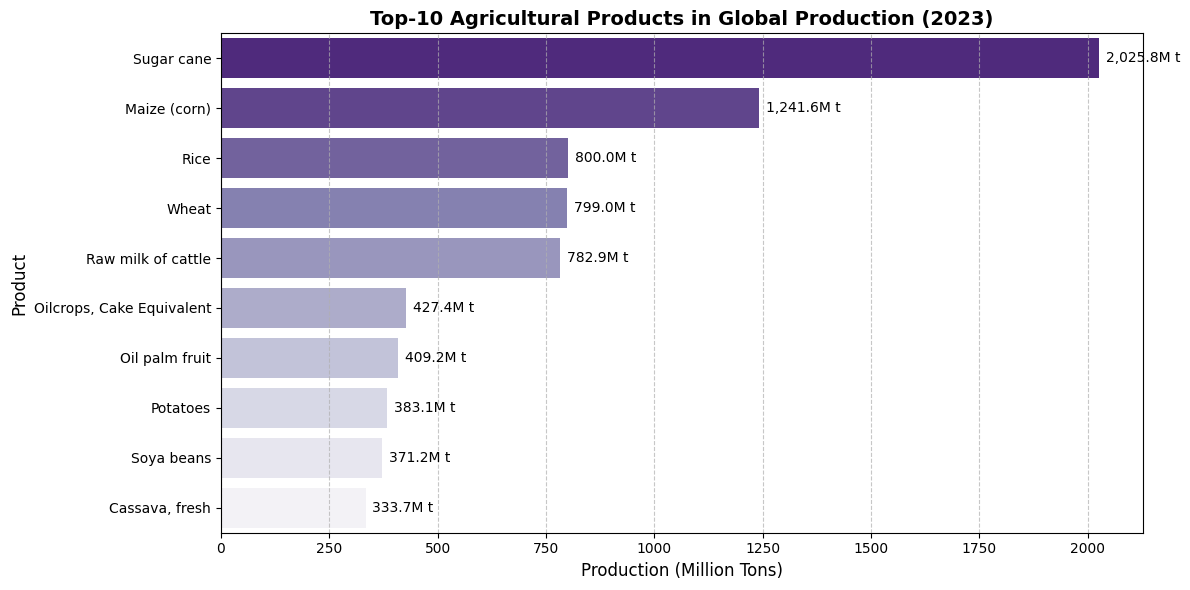

In [11]:
## Top 10 Production for last year ##

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# List of Primary/Total Groups that should be excluded
aggregated_items = [
    'Cereals, primary', 'Sugar Crops Primary', 'Vegetables Primary', 
    'Fruit Primary', 'Roots and Tubers, Total', 'Milk, Total', 
    'Meat, Total', 'Pulses, Total', 'Oilcrops, Primary', 'Citrus Fruit, Total'
]

# Find latest year
latest_year = df_countries['Year'].max()

# Filter the most recent year's records
df_latest = df_countries[df_countries['Year'] == latest_year].dropna(subset=['Production']).copy()

# Filter keeping only non aggregated items
df_filtered = df_latest[
    (~df_latest['Item'].isin(aggregated_items))
]

# Calculate total production per item
top10_products = (
    df_filtered.groupby('Item')['Production']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top10_products.index = top10_products.index + 1

# Convert tonnes to Million Tonnes
top10_products['Production_Million_Tons'] = top10_products['Production'] / 1e6

print(f"🌾 Top-10 Agricultural Products in Global Production (in Millon Tons) {latest_year}:")
print(top10_products[['Item', 'Production_Million_Tons']])

# Bar Plot
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=top10_products, 
    x='Production_Million_Tons', 
    y='Item', 
    hue='Item',
    palette='Purples_r',
    legend=False
)

plt.title(f'Top-10 Agricultural Products in Global Production ({latest_year})', fontsize=14, fontweight='bold')
plt.xlabel('Production (Million Tons)', fontsize=12)
plt.ylabel('Product', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Add price labels to the bars
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{width:,.1f}M t',
                (width, p.get_y() + p.get_height() / 2.),
                ha='left', va='center',
                xytext=(5, 0),
                textcoords='offset points',
                fontsize=10)

plt.tight_layout()
plt.show()

#### 💡 Key Findings & Analytical Insights

* **Dominance of Sugar Cane:** **Sugar cane** stands as the single largest agricultural commodity by mass, exceeding **2.02 billion tonnes** in 2023. This massive volume seems to be heavily driven by tropical industrial producers (e.g., Brazil and India) utilizing crops for both sugar and bioethanol production.
* **The Big Three Staple Grains:** Cereal crops represent the backbone of global food security:
  * **Maize (Corn):** Leads grains at **1,241.56M tonnes**, serving dual roles in livestock feed and industrial processing.
  * **Rice & Wheat:** Virtually tied as primary direct human food sources at **~800M tonnes** and **~799M tonnes**, respectively.
* **Dairy Footprint:** **Raw milk of cattle** is the only livestock-derived product entering the top 5, reaching **782.90M tonnes** globally.
* **Industrial & Oilseed Crops:** Major oilseed commodities—**Oil crops (Cake Equivalent)** (427.43M t), **Oil palm fruit** (409.15M t), and **Soya beans** (371.17M t)—highlight the massive global industrial demand for plant-based oils and animal feed proteins.

### 12. Top Agricultural Commodities in Greece (Latest Year)
Following the global analysis, we narrow our geographical focus to **Greece** to examine its domestic agricultural production profile for the latest available year (`2023`).

**Key Technical Actions:**
* **Geographical Filtering:** Isolated entries where `Area == 'Greece'` while maintaining the exclusion of macro-aggregated item groups.
* **Domestic Ranking:** Aggregated national production volumes to surface the 10 most prominent crops and livestock outputs driving Greek agriculture.

🌾 Top-10 Agricultural Products of Greece (Tons) 2023:
                      Item  Production
1             Maize (corn)  1416690.00
2                    Wheat  1309180.00
3        Raw milk of sheep   943970.00
4                  Oranges   865880.00
5                 Tomatoes   753150.00
6       Raw milk of cattle   669620.00
7   Peaches and nectarines   574780.00
8                   Grapes   564210.00
9              Watermelons   396460.00
10                  Barley   362520.00


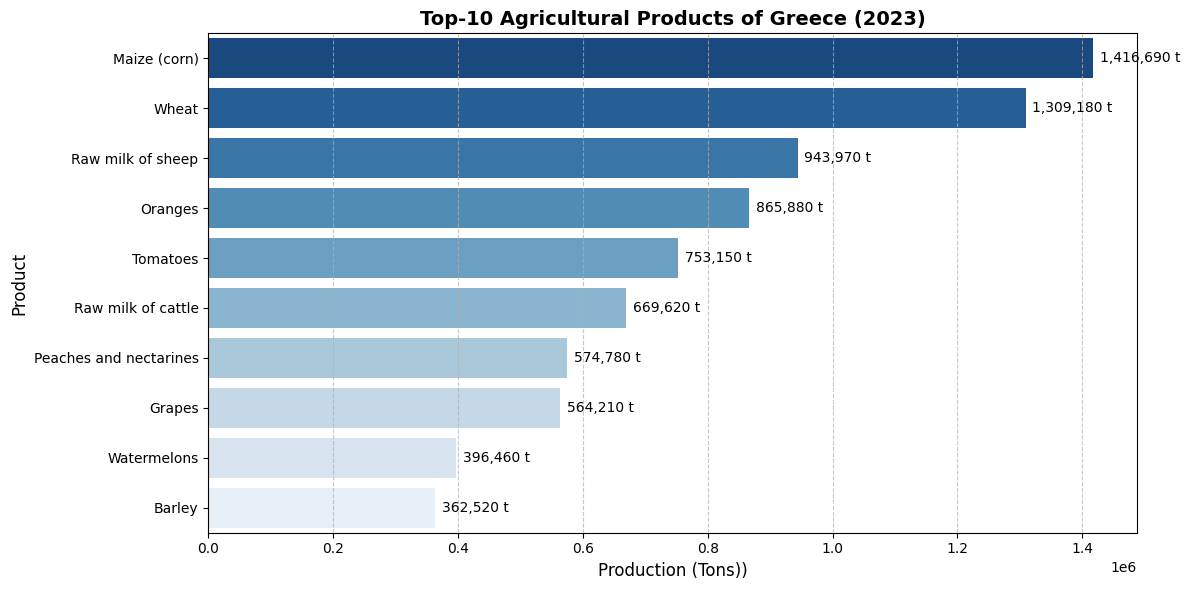

In [12]:
## Top 10 Production of Greece for last year ##

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# List of Primary/Total Groups that should be excluded
aggregated_items = [
    'Cereals, primary', 'Sugar Crops Primary', 'Vegetables Primary', 
    'Fruit Primary', 'Roots and Tubers, Total', 'Milk, Total', 
    'Meat, Total', 'Pulses, Total', 'Oilcrops, Primary', 'Citrus Fruit, Total'
]

# Filter the most recent year's records
df_latest = df_countries[df_countries['Year'] == latest_year].dropna(subset=['Production']).copy()

# Filter keeping only non aggregated items and items for Greece
df_filtered_grc = df_latest[
    (~df_latest['Item'].isin(aggregated_items)) &
    (df_latest['Area']=='Greece')
]

# Calculate total production per item
top10_products_grc = (
    df_filtered_grc.groupby('Item')['Production']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top10_products_grc.index = top10_products_grc.index + 1

print(f"🌾 Top-10 Agricultural Products of Greece (Tons) {latest_year}:")
print(top10_products_grc[['Item', 'Production']])

# Bar Plot
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=top10_products_grc, 
    x='Production', 
    y='Item', 
    hue='Item',
    palette='Blues_r',
    legend=False
)

plt.title(f'Top-10 Agricultural Products of Greece ({latest_year})', fontsize=14, fontweight='bold')
plt.xlabel('Production (Tons))', fontsize=12)
plt.ylabel('Product', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Add price labels to the bars
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{width:,.0f} t',
                (width, p.get_y() + p.get_height() / 2.),
                ha='left', va='center',
                xytext=(5, 0),
                textcoords='offset points',
                fontsize=10)

plt.tight_layout()
plt.show()

#### 💡 Key Findings & Analytical Insights

* **Staple Cereals Lead Volume:** **Maize (corn)** (1.42M tonnes) and **Wheat** (1.31M tonnes) rank as the top two commodities by weight, highlighting the dominance of intensive field crops for feed and human consumption.
* **Significance of Sheep Milk:** **Raw milk of sheep** ranks 3rd at **~944,000 tonnes**, reflecting Greece's specialized livestock sector heavily oriented toward traditional dairy and feta cheese production.
* **Strong Horticultural and Fruit Profile:** The remaining top entries underscore Greece's Mediterranean climate advantage, featuring high-volume fruit and vegetable yields:
  * **Oranges** (865.88K t), **Tomatoes** (753.15K t), **Peaches and nectarines** (574.78K t), **Grapes** (564.21K t), and **Watermelons** (396.46K t).
* **Cattle Milk & Feed Grains:** **Raw milk of cattle** (669.62K t) and **Barley** (362.52K t) round out the top 10 domestic outputs.

### 13. Average Crop Yield Analysis (Global Scale)
To complement production volume metrics, we examine land productivity by analyzing the global average **Yield per Hectare** (`t/ha`) for individual crop items in the latest year (`2023`).

**Key Technical Actions:**
* **Unit Identification & Conversion:** Filtered initial dataset items mapped to the `kg/ha` yield standard and converted values to tonnes per hectare (`t/ha`) for intuitive cross-commodity comparison.
* **Exclusion & Aggregation:** Ensured macro-aggregates are excluded, computing the global mean yield per crop across active producing nations.

🌾 Top-10 Crops in Yield Per Hectare (2023):
                                                 Item  Yield_t_ha
1                              Cucumbers and gherkins       61.16
2                                            Tomatoes       60.70
3                                          Sugar cane       57.58
4                                          Sugar beet       48.74
5                              Eggplants (aubergines)       35.11
6                                         Watermelons       30.60
7   Chillies and peppers, green (Capsicum spp. and...       30.15
8                                 Carrots and turnips       28.81
9                                            Cabbages       27.18
10                                            Papayas       26.90


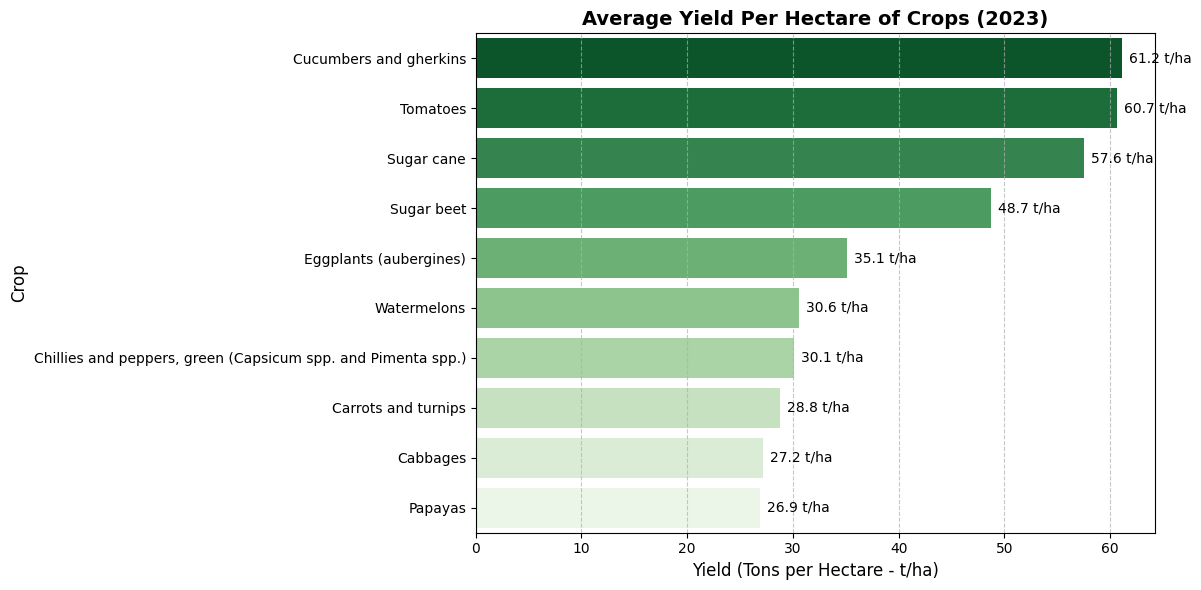

In [13]:
# Average Yield per Hectare of Crops for latest year

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Find Crop tems of the initial dataset as Items whose Yield unit is 'kg/ha'
crop_items = df_all_data_noflag[
    (df_all_data_noflag['Element'] == 'Yield') & 
    (df_all_data_noflag['Unit'] == 'kg/ha')
]['Item'].unique()


# Filtering for latest year, crop items and non aggregated items
df_latest_crops = df_countries[
    (df_countries['Year'] == latest_year) & 
    (df_countries['Item'].isin(crop_items)) & 
    (~df_countries['Item'].isin(aggregated_items))
].dropna(subset=['Yield']).copy()

# Convert kg/ha to t/ha
df_latest_crops['Yield_t_ha'] = df_latest_crops['Yield'] / 1000

# Calculate average global yield per crop product
top10_crop_yield = (
    df_latest_crops.groupby('Item')['Yield_t_ha']
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top10_crop_yield.index = top10_crop_yield.index + 1

print(f"🌾 Top-10 Crops in Yield Per Hectare ({latest_year}):")
print(top10_crop_yield)

# Plot
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=top10_crop_yield, x='Yield_t_ha', y='Item', hue='Item', palette='Greens_r', legend=False)
plt.title(f'Average Yield Per Hectare of Crops ({latest_year})', fontsize=14, fontweight='bold')
plt.xlabel('Yield (Tons per Hectare - t/ha)', fontsize=12)
plt.ylabel('Crop', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Add price labels to the bars
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{width:,.1f} t/ha',
                (width, p.get_y() + p.get_height() / 2.),
                ha='left', va='center',
                xytext=(5, 0),
                textcoords='offset points',
                fontsize=10)

plt.tight_layout()
plt.show()

#### 💡 Key Findings & Analytical Insights

* **High-Moisture Horticulture Leads Land Efficiency:** Vegetable and high-water content crops dominate the top of the yield efficiency spectrum due to multi-harvest cycles, intensive greenhouse cultivation, and massive fruit/vegetable mass:
  * **Cucumbers and gherkins** (61.16 t/ha) and **Tomatoes** (60.70 t/ha) lead global land productivity.
* **Industrial & Root Crops High Mass Conversion:** 
  * **Sugar cane** (57.58 t/ha) and **Sugar beet** (48.74 t/ha) show exceptional biomass output per unit of land.
* **Fruit & Vegetable Varieties:** The rest of the top 10 features dense agricultural yields like **Eggplants** (35.11 t/ha), **Watermelons** (30.60 t/ha), and **Green chillies/peppers** (30.15 t/ha).

### 14. Global Average Milk Yield per Animal Analysis
Shifting from land productivity to livestock performance, we analyze the global average milk yield per animal (`kg/An`) across different dairy-producing species for the latest available year (`2023`).

**Key Technical Actions:**
* **Species Filtering:** Filtered country-level records matching predefined `milk_types` for the latest year.
* **Unit Standardization:** Converted base yield figures into uniform kilograms per animal (`kg/An`) for direct comparison.
* **Global Aggregation:** Computed world-wide mean yields grouped by animal species to benchmark macro-productivity differences.

🥛 Average Global Milk Yield in kg/An (2023):
                  Item  Milk_Yield_kg
1   Raw milk of cattle        3105.94
2  Raw milk of buffalo        1197.61
3    Raw milk of camel         346.87
4    Raw milk of goats         142.40
5    Raw milk of sheep          77.22


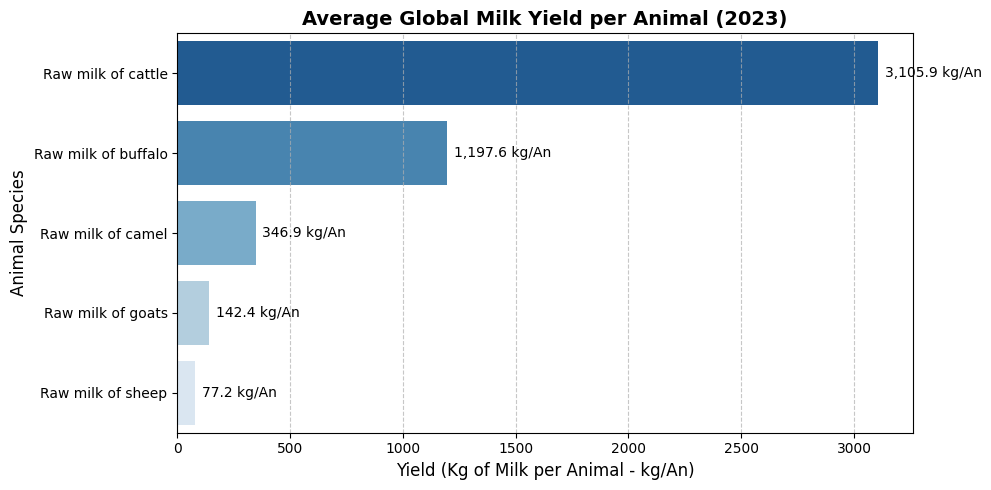

In [14]:
# Average Global Milk Yield per Animal for latest year

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Make dataframe containing only milk items for the latest year
df_milk = df_countries[
    (df_countries['Year'] == latest_year) & 
    (df_countries['Item'].isin(milk_types))
].dropna(subset=['Yield']).copy()

# Convert 100g/An to kg/An
df_milk['Milk_Yield_kg'] = df_milk['Yield'] / 10

# Average Global Milk Yield per Animal
milk_summary = (
    df_milk.groupby('Item')['Milk_Yield_kg']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

milk_summary.index = milk_summary.index + 1

print(f"🥛 Average Global Milk Yield in kg/An ({latest_year}):")
print(milk_summary)

# Plot
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=milk_summary, x='Milk_Yield_kg', y='Item', hue='Item', palette='Blues_r', legend=False)
plt.title(f'Average Global Milk Yield per Animal ({latest_year})', fontsize=14, fontweight='bold')
plt.xlabel('Yield (Kg of Milk per Animal - kg/An)', fontsize=12)
plt.ylabel('Animal Species', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Add price labels to the bars
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{width:,.1f} kg/An',
                (width, p.get_y() + p.get_height() / 2.),
                ha='left', va='center',
                xytext=(5, 0),
                textcoords='offset points',
                fontsize=10)

plt.tight_layout()
plt.show()

#### 💡 Key Findings & Analytical Insights

* **Global Dairy Efficiency Hierarchy:** 
  * **Cattle** dominate per-animal productivity globally at **3,105.94 kg/An**, powered by intensive dairy systems. 
  * Small ruminants sit at the lower end of the global yield spectrum (**Goats at 142.40 kg/An** and **Sheep at 77.22 kg/An**).
* **The Productivity vs. Total Output Paradox (Crucial Insight):**
  * Globally, sheep milk ranks **last** in average yield per animal. 
  * However, as seen earlier in Greece's domestic profile (Section 12), **Raw milk of sheep** ranks among the absolute top national outputs (**~944,000 tonnes**). 
  * This creates a fascinating agricultural contrast: while sheep have low biological milk yield per head compared to cattle worldwide, Greece achieves massive aggregate production through high livestock population density and specialized pastoral farming geared toward traditional dairy products (e.g., Feta).

### 15. Global Average Carcass Weight (Meat Yield per Animal) Analysis
Continuing our livestock performance evaluation, we examine the global average **Carcass Weight** (`kg/An`) across large meat-producing animals for the latest available year (`2023`).

**Key Technical Actions:**
* **Species Filtering:** Filtered country-level records matching large livestock meat items (`large_animals_meat`) for the latest year.
* **Unit Standardization:** Converted base yield figures (stored as carcass weights per slaughtered head) into uniform kilograms per animal (`kg/An`).
* **Global Aggregation:** Computed worldwide mean carcass weights grouped by animal type to assess biological and industrial meat yields per head.

Average Carcass Weight) in kg/An (2023):
                                             Item  Carcass_Weight_kg
1  Meat of cattle with the bone, fresh or chilled             203.39
2               Meat of buffalo, fresh or chilled             200.30
3     Meat of pig with the bone, fresh or chilled              67.13
4                 Meat of sheep, fresh or chilled              17.91
5                  Meat of goat, fresh or chilled              14.36


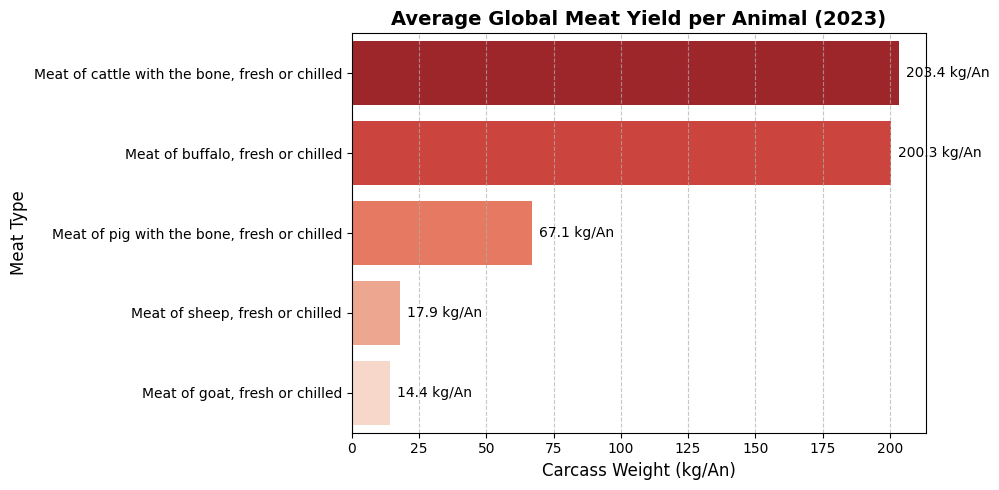

In [15]:
# Average Global Meat Yield per Animal for latest year

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Make dataframe containing only main meat items for the latest year
df_meat_large = df_countries[
    (df_countries['Year'] == latest_year) & 
    (df_countries['Item'].isin(large_animals_meat))
].dropna(subset=['Yield/Carcass Weight']).copy()

# Convert from 100g/An to kg/An
df_meat_large['Carcass_Weight_kg'] = df_meat_large['Yield/Carcass Weight'] / 10

# Calculation of average global carcass weight
meat_summary = (
    df_meat_large.groupby('Item')['Carcass_Weight_kg']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

meat_summary.index = meat_summary.index + 1

print(f"Average Carcass Weight) in kg/An ({latest_year}):")
print(meat_summary)

# Plot
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=meat_summary, x='Carcass_Weight_kg', y='Item', hue='Item', palette='Reds_r', legend=False)
plt.title(f'Average Global Meat Yield per Animal ({latest_year})', fontsize=14, fontweight='bold')
plt.xlabel('Carcass Weight (kg/An)', fontsize=12)
plt.ylabel('Meat Type', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Add price labels to the bars
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{width:,.1f} kg/An',
                (width, p.get_y() + p.get_height() / 2.),
                ha='left', va='center',
                xytext=(5, 0),
                textcoords='offset points',
                fontsize=10)

plt.tight_layout()
plt.show()

#### 💡 Key Findings & Analytical Insights

* **Large Bovine Domination in Carcass Mass:** 
  * **Cattle** (203.39 kg/An) and **Buffalo** (200.30 kg/An) yield the highest amount of meat per slaughtered head globally, reflecting their massive biological scale.
* **Mid-Tier & Small Ruminants:**
  * **Pigs** average a moderate **67.13 kg/An**, balancing high-frequency reproduction cycles with substantial individual meat output.
  * Small ruminants register low individual carcass weights—**Sheep** at **17.91 kg/An** and **Goats** at **14.36 kg/An**—reinforcing why fulfilling national meat demand requires significantly higher processing heads compared to cattle.

### 16. Top Producing Countries for Core Global Cereals
To evaluate the geographical concentration of staple food production, we examine the top 10 producing countries for the three foundational cereal grains—**Maize (corn)**, **Rice**, and **Wheat**—for the latest available year (`2023`).

**Key Technical Actions:**
* **Multipanel Visualization:** Generated a 3-panel subplot layout to compare national production volumes side by side using tailored color palettes.
* **Unit Scaling & Ranking:** Scaled output quantities to Million Metric Tonnes ($M\ t$) and ranked entities within each specific crop category.


🌾 Top-10 Producers for Maize (corn) (2023):
                        Area  Production_MT
1   United States of America         389.69
2            China, mainland         288.84
3                     Brazil         131.95
4                  Argentina          41.41
5                      India          38.09
6                    Ukraine          31.03
7                     Mexico          27.55
8                  Indonesia          19.99
9         Russian Federation          16.60
10              South Africa          16.43

🌾 Top-10 Producers for Rice (2023):
               Area  Production_MT
1             India         206.73
2   China, mainland         206.60
3        Bangladesh          58.61
4         Indonesia          53.98
5          Viet Nam          43.50
6          Thailand          33.07
7           Myanmar          25.65
8       Philippines          20.06
9          Pakistan          14.80
10         Cambodia          12.90

🌾 Top-10 Producers for Wheat (2023):
           

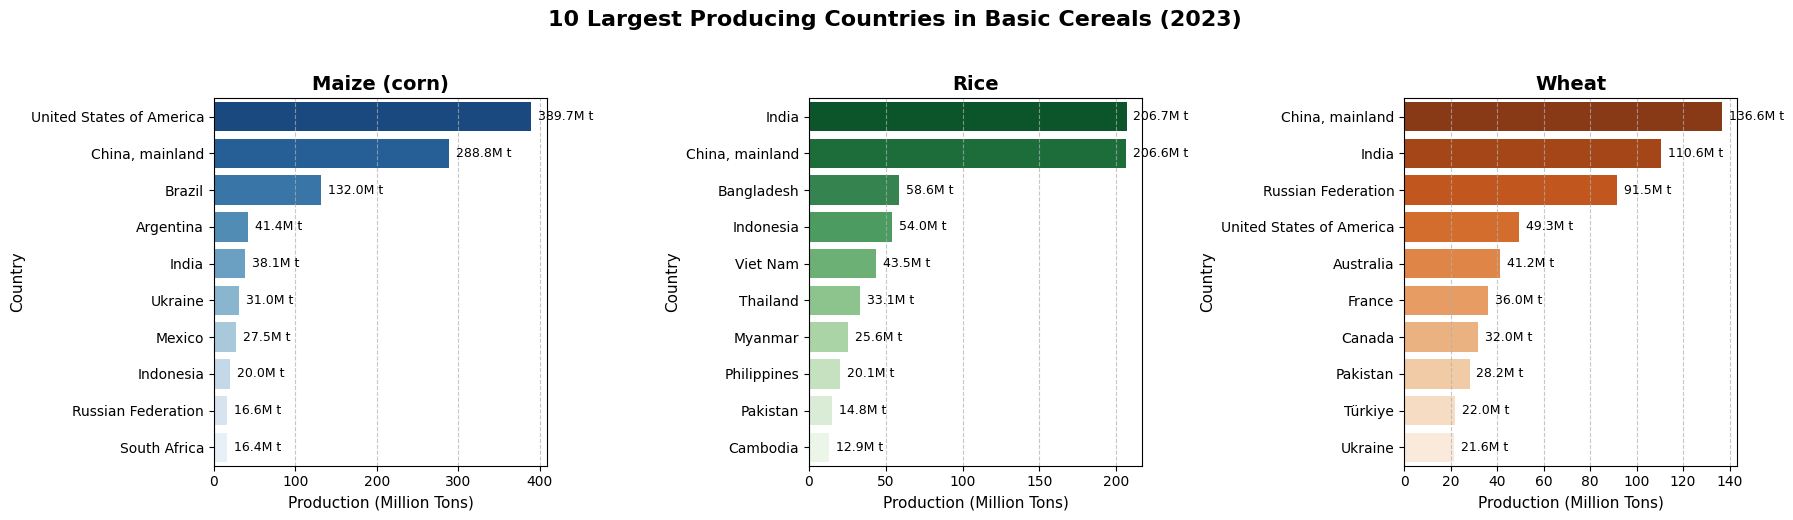

In [16]:
# 10 Largest Producing Countries in Basic Cereals (Maize (corn), Rice , Wheat)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


top_crops = ['Maize (corn)', 'Rice', 'Wheat']

# Creating dataframe containing only top crops for latest year
df_top_crops = df_countries[
    (df_countries['Year'] == latest_year) & 
    (df_countries['Item'].isin(top_crops))
].dropna(subset=['Production']).copy()

# Convert to million tons
df_top_crops['Production_MT'] = df_top_crops['Production'] / 1e6


# Create Plot containing 3 Subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=False)
palette_list = ['Blues_r', 'Greens_r', 'Oranges_r']


for idx, crop in enumerate(top_crops):
    # Find Top-10 countries for certain crop
    top_countries = (
        df_top_crops[df_top_crops['Item'] == crop]
        .groupby('Area')['Production_MT']
        .sum()
        .sort_values(ascending=False)
        .head(10)
        .reset_index()
    )
   
    top_countries.index = top_countries.index + 1

    
    print(f"\n🌾 Top-10 Producers for {crop} ({latest_year}):")
    print(top_countries)
    
    # Subplots
    ax = axes[idx]
    sns.barplot(
        data=top_countries, 
        x='Production_MT', 
        y='Area', 
        hue='Area',
        ax=ax, 
        palette=palette_list[idx],
        legend=False
    )
    ax.set_title(f'{crop}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Production (Million Tons)', fontsize=11)
    ax.set_ylabel('Country', fontsize=11)
    ax.grid(axis='x', linestyle='--', alpha=0.7)
    
    # Add price labels to the bars
    for p in ax.patches:
        width = p.get_width()
        ax.annotate(f'{width:,.1f}M t',
                    (width, p.get_y() + p.get_height() / 2.),
                    ha='left', va='center',
                    xytext=(5, 0),
                    textcoords='offset points',
                    fontsize=9)

plt.suptitle(f'10 Largest Producing Countries in Basic Cereals ({latest_year})', fontsize=16, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

#### 💡 Key Findings & Analytical Insights

* **Maize (Corn) - Western Hemisphere & Industrial Power:** 
  * The **United States of America** dominates global maize production at an overwhelming **389.69M tonnes**, followed closely by **China, mainland** (288.84M tonnes) and **Brazil** (131.95M tonnes). These three nations dictate the global feed-grain and bio-industrial market.
* **Rice - Asian Food Security Engine:** 
  * Rice production exhibits an extreme geographic concentration across South and Southeast Asia. **India** (206.73M tonnes) and **China, mainland** (206.60M tonnes) run virtually neck-and-neck at the top, followed by regional powerhouses like Bangladesh, Indonesia, and Vietnam.
* **Wheat - Broad Global Distribution:** 
  * Wheat production is more widely distributed across northern temperate zones and major agricultural economies. **China, mainland** leads at **136.59M tonnes**, with **India** (110.55M tonnes) and the **Russian Federation** (91.50M tonnes) forming a formidable top tier. European producers (France) and traditional exporters (USA, Australia, Canada) round out the global supply chain.

### 17. Highest-Yielding Countries in Basic Cereals (`kg/ha`)
Shifting from gross national production volume to land productivity efficiency, we examine the top 10 countries ranked by average **Yield per Hectare** (`kg/ha`) for **Maize (corn)**, **Rice**, and **Wheat** in `2023`.

**Key Technical Actions:**
* **Yield Extraction:** Filtered country-level records containing valid yield measurements for the core cereal triad.
* **Comparative Ranking:** Grouped and sorted national averages to uncover the world's most land-efficient producers, challenging assumptions tied purely to total output volume.


🌾 Top-10 Highest-Yielding Countries for Maize (corn) (2023):
                                Area    Yield
1               United Arab Emirates 23306.50
2                              Qatar 20979.20
3                             Kuwait 18201.90
4                             Israel 17344.10
5                         Tajikistan 14393.40
6   Saint Vincent and the Grenadines 14066.70
7                         Uzbekistan 12735.90
8                              Spain 11818.90
9                          Mauritius 11643.40
10          United States of America 11130.60

🌾 Top-10 Highest-Yielding Countries for Rice (2023):
                        Area   Yield
1                 Tajikistan 9874.20
2                  Australia 9516.20
3                    Uruguay 9338.10
4                      Egypt 8715.90
5   United States of America 8572.80
6                 Uzbekistan 8418.30
7                       Peru 8073.80
8                    Türkiye 8027.10
9                    Morocco 8000.90
10      

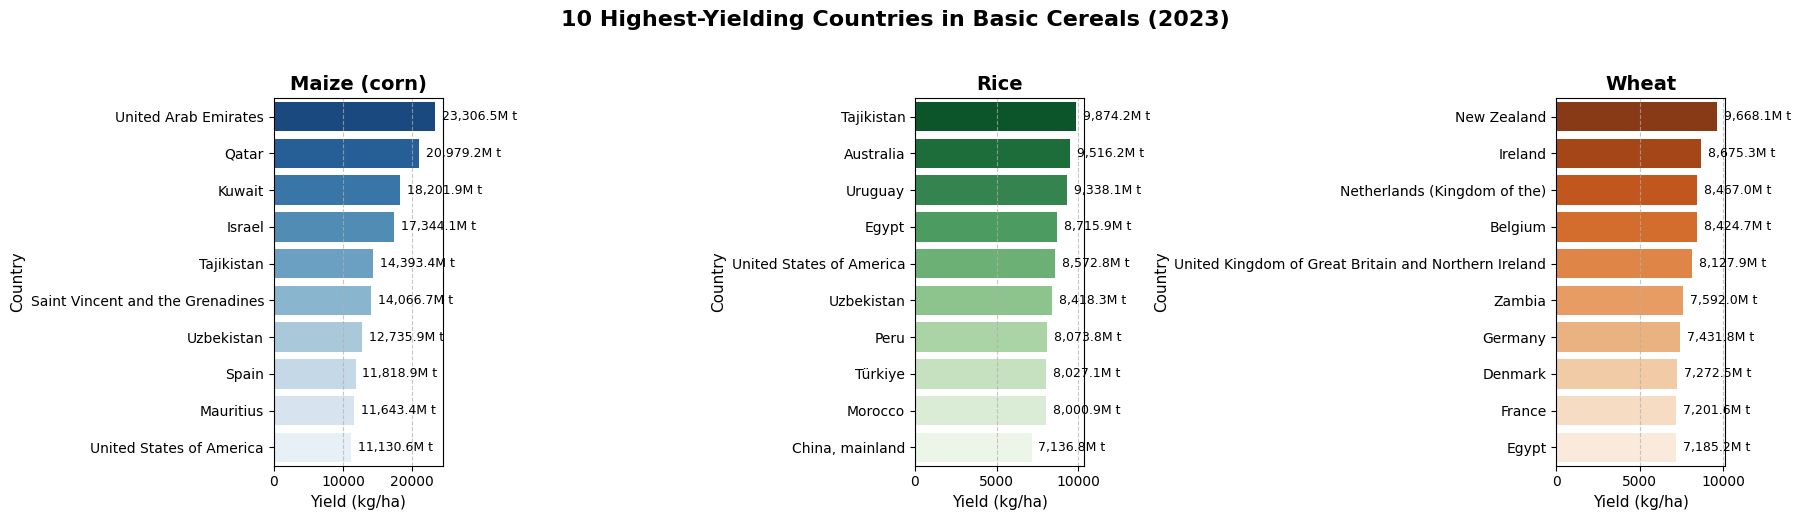

In [17]:
# 10 Highest-Yielding Countries in Basic Cereals (Maize, Rice & Wheat)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


top_crops = ['Maize (corn)', 'Rice', 'Wheat']

# Creating dataframe containing only top crops for latest year
df_top_crops = df_countries[
    (df_countries['Year'] == latest_year) & 
    (df_countries['Item'].isin(top_crops))
].dropna(subset=['Yield']).copy()


# Create Plot containing 3 Subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=False)
palette_list = ['Blues_r', 'Greens_r', 'Oranges_r']


for idx, crop in enumerate(top_crops):
    # Find Top-10 countries for certain crop
    top_countries = (
        df_top_crops[df_top_crops['Item'] == crop]
        .groupby('Area')['Yield']
        .sum()
        .sort_values(ascending=False)
        .head(10)
        .reset_index()
    )
   
    top_countries.index = top_countries.index + 1

    
    print(f"\n🌾 Top-10 Highest-Yielding Countries for {crop} ({latest_year}):")
    print(top_countries)
    
    # Subplots
    ax = axes[idx]
    sns.barplot(
        data=top_countries, 
        x='Yield', 
        y='Area', 
        hue='Area',
        ax=ax, 
        palette=palette_list[idx],
        legend=False
    )
    ax.set_title(f'{crop}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Yield (kg/ha)', fontsize=11)
    ax.set_ylabel('Country', fontsize=11)
    ax.grid(axis='x', linestyle='--', alpha=0.7)
    
    # Add price labels to the bars
    for p in ax.patches:
        width = p.get_width()
        ax.annotate(f'{width:,.1f}M t',
                    (width, p.get_y() + p.get_height() / 2.),
                    ha='left', va='center',
                    xytext=(5, 0),
                    textcoords='offset points',
                    fontsize=9)

plt.suptitle(f'10 Highest-Yielding Countries in Basic Cereals ({latest_year})', fontsize=16, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

#### 💡 Key Findings & Analytical Insights (The Yield Paradox)

* **The GCC & Controlled-Environment Farming (Maize Surprise):** 
  * The top of the global maize yield ranking features **United Arab Emirates** (23,306.50 kg/ha), **Qatar**, and **Kuwait**. 
  * *Analytical Context:* This is a classic artifact of micro-scale, hyper-intensive agricultural systems (such as high-tech greenhouses and hydroponics/controlled irrigation in desert environments) producing tiny physical volumes over minuscule harvested areas, which artificially inflates the per-hectare metric relative to open-field farming powerhouses like the USA.
* **Rice Productivity & Specialized Irrigation:** 
  * For rice, land efficiency is led by **Tajikistan** (9,874.20 kg/ha) and **Australia** (9,516.20 kg/ha), alongside expert Mediterranean/arid producers like **Egypt** (8,715.90 kg/ha) which utilize intense controlled flooding and high-yield seed varieties.
* **Wheat & Western European Agronomic Dominance:** 
  * Unlike maize, the wheat yield leaders reflect true large-scale agronomic efficiency. **New Zealand** (9,668.10 kg/ha), **Ireland**, the **Netherlands**, **Belgium**, and the **UK** dominate due to temperate maritime climates, fertile soils, and advanced fertilization/management practices.

### 18. Mediterranean Olive & Olive Oil Production Analysis (2021 Baseline)
While our general global analysis utilized the latest dataset year (`2023`), official agricultural reporting for specific structural crops like olives and olive oil exhibits a reporting lag across several nations (including Greece). To ensure complete national representation, we establish a dedicated **2021 baseline** for olive-specific products.

**Key Technical Actions:**
* **Year Adjustment:** Filtered records specifically for `2021` to capture comprehensive reporting for Mediterranean basin economies.
* **Product Disaggregation:** Evaluated both table/crushing `Olives` and processed `Olive oil` to compare raw agricultural harvest with industrial extraction output.
* **Unit Scaling:** Scaled production quantities to Thousand Metric Tonnes ($kT$) for intuitive comparison.


 Top-10 Producers for Olives (2021):
                    Area  Production_kT
1                  Spain        8256.55
2                 Greece        3045.10
3                  Italy        2270.63
4                Türkiye        1738.68
5                Morocco        1590.50
6               Portugal        1375.75
7                  Egypt        1056.55
8                Algeria         704.62
9                Tunisia         700.00
10  Syrian Arab Republic         566.04

 Top-10 Producers for Olive oil (2021):
                    Area  Production_kT
1                  Spain        1493.01
2                  Italy         338.63
3                 Greece         255.71
4               Portugal         228.95
5                Türkiye         222.10
6                Morocco         194.90
7                Tunisia         144.20
8   Syrian Arab Republic         103.89
9                Algeria          71.00
10                 Egypt          44.10


/tmp/ipykernel_16/1063073415.py:70: UserWarning: Glyph 129746 (\N{OLIVE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129746 (\N{OLIVE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


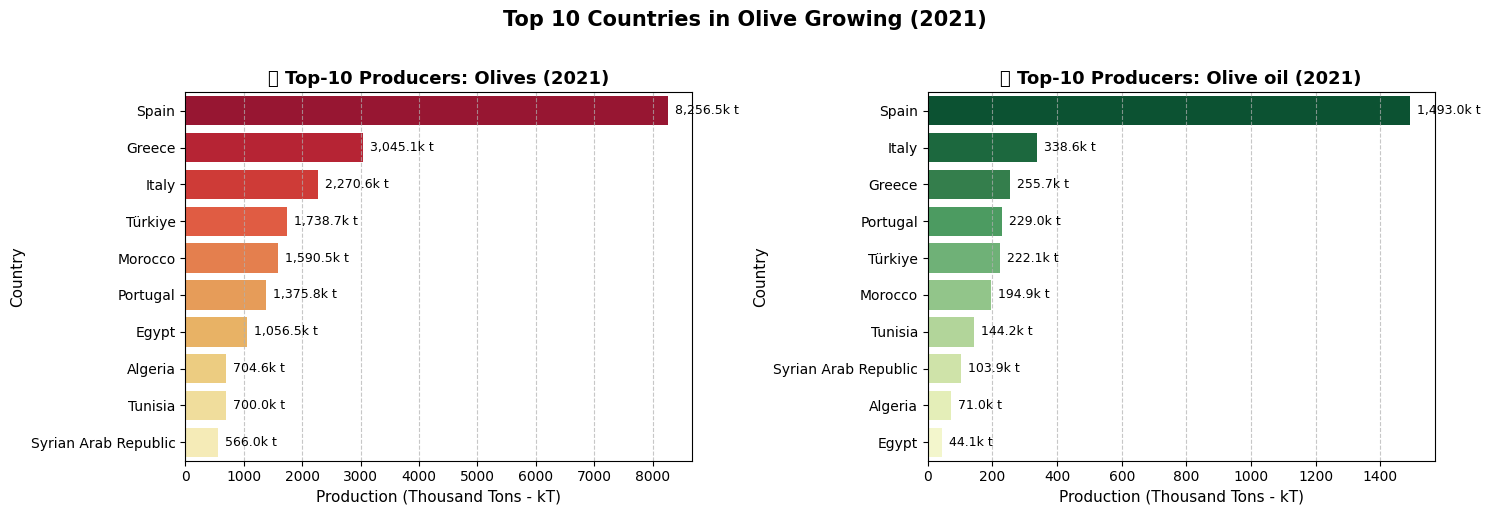

In [18]:
# Top 10 Countries in Olive Growing for 2021

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


olive_products = ['Olives', 'Olive oil']


# Create dataframe containing only olive products
df_olive_products = df_countries[
    (df_countries['Year'] == 2021) &
    (df_countries['Item'].isin(olive_products))        
].dropna(subset=['Production']).copy()

# Convert to Thousant tons
df_olive_products['Production_kT'] = df_olive_products['Production'] / 1000

# Create Plot containing 2 Subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
palette_list = ['YlOrRd_r', 'YlGn_r']


for idx, product in enumerate(olive_products):
    # Find Top-10 countries for olive products
    olive_countries = (
        df_olive_products[df_olive_products['Item'] == product]
        .groupby('Area')['Production_kT']
        .sum()
        .sort_values(ascending=False)
        .head(10)
        .reset_index()
    )

    olive_countries.index = olive_countries.index+1

    print(f'\n Top-10 Producers for {product} (2021):')
    print(olive_countries)

    
    # Subplots
    ax = axes[idx]
    sns.barplot(
        data=olive_countries, 
        x='Production_kT', 
        y='Area', 
        hue='Area', 
        ax=ax, 
        palette=palette_list[idx], 
        legend=False
    )
    
    ax.set_title(f'🫒 Top-10 Producers: {product} ({2021})', fontsize=13, fontweight='bold')
    ax.set_xlabel('Production (Thousand Tons - kT)', fontsize=11)
    ax.set_ylabel('Country', fontsize=11)
    ax.grid(axis='x', linestyle='--', alpha=0.7)
    
    # Add price labels to the bars
    for p in ax.patches:
        width = p.get_width()
        ax.annotate(f'{width:,.1f}k t',
                    (width, p.get_y() + p.get_height() / 2.),
                    ha='left', va='center',
                    xytext=(5, 0),
                    textcoords='offset points',
                    fontsize=9)

plt.suptitle(f'Top 10 Countries in Olive Growing ({2021})', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

#### 💡 Key Findings & Analytical Insights

* **The Mediterranean Basin Monopoly:** 
  * Olive growing and processing are overwhelmingly concentrated in the Mediterranean climate zone, completely dominated by Southern European and North African producers.
* **Table/Crushing Olives Volume vs. Extraction (`Olives` vs. `Olive oil`):**
  * **Spain** is the undisputed global leader in both categories, producing an immense **8,256.55 kT** of raw olives translating to **1,493.01 kT** of olive oil.
  * **Greece's Prominent Standing:** Greece secures an outstanding **2nd place globally in raw olive production** (**3,045.10 kT**) and ranks **3rd globally in olive oil production** (**255.71 kT**), outperforming or competing tightly with historical heavyweights like Italy.
* **Industrial Conversion Ratios:** The data clearly illustrates the massive weight reduction between raw harvested olives and final oil extraction, highlighting high-efficiency processing sectors in countries like Portugal, Tunisia, and Turkey.

### 19. Historical Item Filtering for Greek Agricultural Timeline (1980–2021)
To construct a robust historical timeline of agricultural production in **Greece** spanning over four decades (1980–2021), we must precisely identify all distinct FAOSTAT item names associated with our four core pillars: **Olive**, **Cotton**, **Wheat**, and **Grapes**.

**Key Technical Actions:**
* **Case-Insensitive Substring Matching:** Scanned the Greek subset of `df_countries` using keyword filters to capture all raw, processed, and secondary sub-items.
* **Result Inspection:** Validated that variations (such as ginned vs. unginned cotton and table olives vs. olive oil) are correctly caught for downstream historical aggregation.

In [19]:
# Name detection for Olive, Cotton, Wheat and Grapes
items_to_check = ['olive', 'cotton', 'wheat', 'grape']
found_greece_items = []

for term in items_to_check:
    matched = df_countries[
        (df_countries['Area'] == 'Greece') & 
        (df_countries['Item'].str.contains(term, case=False, na=False))
    ]['Item'].unique()
    found_greece_items.extend(matched)

print("Found the following products for Greece:")
print(list(set(found_greece_items)))

Found the following products for Greece:
['Wheat', 'Cottonseed oil', 'Grapes', 'Cotton seed', 'Pomelos and grapefruits', 'Seed cotton, unginned', 'Cotton lint, ginned', 'Olive oil', 'Olives']


#### 💡 Key Findings & Analytical Insights

* **Keyword Overlap & Precision (The "Grapefruit" Artifact):**
  * The search correctly captured core agricultural commodities: `Olives`, `Olive oil`, `Seed cotton, unginned`, `Cotton lint, ginned`, `Cotton seed`, `Cottonseed oil`, `Grapes`, and `Wheat`.
  * *Methodological Note:* The term `'grape'` triggered a false positive match for **`Pomelos and grapefruits`**. This highlights the necessity of manual curation or strict boundary matching before building multi-product historical time-series plots to prevent contaminating citrus statistics with grape data.

### 20. Historical Production Timeline in Greece (1980–2021)
To track long-term structural changes, we construct a 40-year historical time-series plot mapping the production evolution of Greece's foundational crop pillars: **Olives/Olive oil**, **Cotton** (*Seed cotton, unginned*), **Grapes**, and **Wheat** from `1980` to `2021`.

**Key Technical Actions:**
* **Multi-Decade Filtering:** Extracted Hellenic records spanning 1980 onwards across standard target commodities.
* **Unit Standardization & Visualization:** Scaled values to Thousand Metric Tonnes ($kT$) and rendered a multi-line temporal graph utilizing distinct markers and a unified color palette.

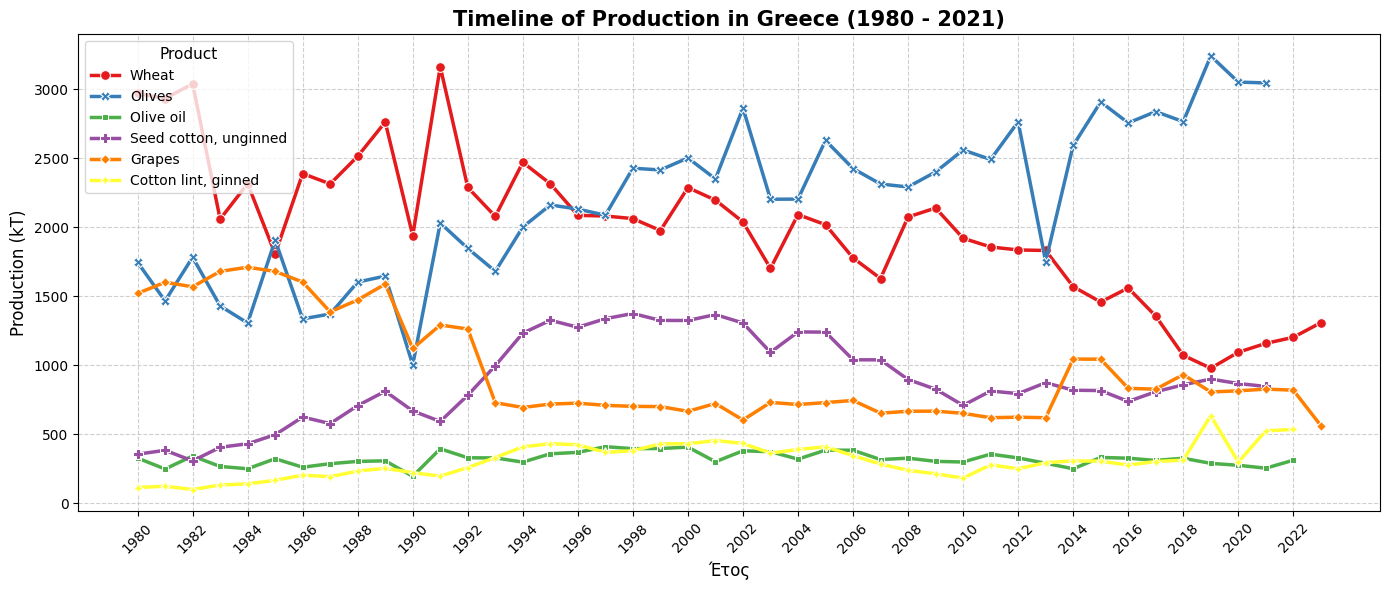

In [20]:
# Timeline of 4 Basic Crops (Olive products, Cotton, Grapes, Wheat) Production in Greece (1980 - 2021)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Select products
target_items = ['Olives', 'Olive oil', 'Seed cotton, unginned', 'Cotton lint, ginned', 'Grapes', 'Wheat'] 

# Data Filtering for Greexe and Production
df_greece_ts = df_countries[
    (df_countries['Area'] == 'Greece') & 
    (df_countries['Item'].isin(target_items)) &
    (df_countries['Year'] >= 1980)
].dropna(subset=['Production']).copy()

# Convert to Thousand Tons - kT
df_greece_ts['Production_kTons'] = df_greece_ts['Production'] / 1000

# Plot
plt.figure(figsize=(14, 6))

ax = sns.lineplot(
    data=df_greece_ts, 
    x='Year', 
    y='Production_kTons', 
    hue='Item', 
    style='Item',
    markers=True, 
    dashes=False, 
    linewidth=2.5,
    markersize=7,
    palette='Set1'
)

plt.title('Timeline of Production in Greece (1980 - 2021)', fontsize=15, fontweight='bold')
plt.xlabel('Έτος', fontsize=12)
plt.ylabel('Production (kT)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(range(1980, df_greece_ts['Year'].max() + 1, 2), rotation=45) # Labels for every 2 years

plt.legend(title='Product', title_fontsize='11', fontsize='10', loc='upper left')

plt.tight_layout()
plt.show()

#### 💡 Key Findings & Agronomic Insights (1980–2021)

* **🫒 Olives: Alternate Bearing Pattern (Biennial Bearing) & Growth:**
  * **Zig-Zag Fluctuations:** The curve for olives displays dramatic year-to-year spikes and drops. This visually captures the biological phenomenon of **alternate bearing**, where an exceptionally high-yield harvest year depletes the trees' nutrient reserves, causing naturally lower yields in the following season.
  * **Long-Term Trajectory:** Despite annual swings, the multi-decade baseline rose steadily from 1980 through the early 2000s, possibly driven by grove expansions, modernized irrigation systems, and optimized harvesting techniques.

* **🌾 Wheat: Policy-Driven Structural Decline:**
  * **The High-Yield Era (1980s–1990s):** Wheat production peaked historically above **3,000 kT**, strongly supported by early Common Agricultural Policy (CAP) coupled subsidies directly tied to produced volume.
  * **The Post-2004 Pivot:** Following major CAP reforms—specifically the decoupling of subsidies from direct output—farmers shifted away from low-margin staples toward higher-value crops, causing a permanent structural reduction and stabilization at lower production thresholds.

* **⚪ Cotton: EU Entry Surge & Resource Stabilization:**
  * **Post-1981 Expansion:** Greece's accession to the EEC in 1981 triggered a massive expansion in cotton farming (*Seed cotton, unginned*), transforming Greece into Europe's leading cotton producer and reaching peak levels through the mid-1990s.
  * **Environmental Rationalization:** Post-2000 output stabilized within a managed range (~1,000–1,500 kT), constrained by water resource limits (high irrigation demands) and stricter EU environmental standards.

* **🍇 Grapes: Regulatory Grubbing-Up vs. Financial Crisis Revival:**
  * **The 1993 Production Drop (EEC Vine Grubbing Scheme):** The sharp contraction around 1993 corresponds directly with **EEC Regulation 1442/88**, which offered heavy financial premiums for permanent vine grubbing-up (εκρίζωση αμπελώνων) to curb European wine overproduction ("wine lakes") and prohibited new vineyard plantings.
  * **The Post-2012 Rebound:** The uptick observed around 2013 aligns with the Greek financial crisis. High urban unemployment prompted a return to family-owned rural land and traditional viticulture, combined with a structural surge in boutique wineries targeting native grape varieties and international exports.

#### 🎯 Core Analytical Takeaway
The 40-year temporal analysis demonstrates that Greek agricultural output is shaped not only by biological and climatic conditions, but is **profoundly dictated by European Common Agricultural Policy (CAP) reforms**, market incentives, and macro-economic socioeconomic shifts.

### 21. Crop Yield Productivity Comparison: Greece vs. European Union (2021)
To benchmark Hellenic agricultural efficiency against regional standards, we compare the per-hectare yield (`t/ha`) of three major crops—**Wheat**, **Maize (corn)**, and **Olives**—between **Greece** and the aggregate **European Union (27 countries)** for `2021`.

**Key Technical Actions:**
* **Cross-Dataset Integration:** Merged country-level records (`df_countries`) with macro-regional aggregates (`df_aggregates`).
* **Unit Standardization:** Standardized yield values into metric tonnes per hectare ($t/ha$) to evaluate land productivity differentials.


📊 Yield Comparison (t/ha) - Grecce vs ΕΕ (2021):
                  Area          Item  Yield_t_ha
1               Greece         Wheat        2.82
2               Greece  Maize (corn)       11.24
3               Greece        Olives        3.68
4  European Union (27)         Wheat        5.74
5  European Union (27)  Maize (corn)        7.90
6  European Union (27)        Olives        3.00


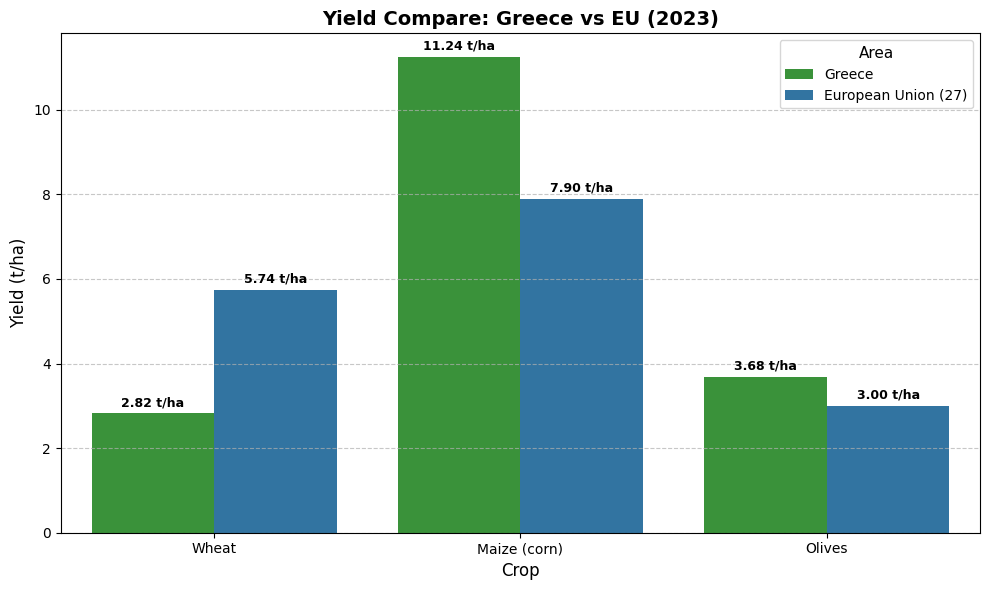

In [21]:
# Hectare Yield Comparison (Wheat, Maize, Olives) for 2021: Greece vs EU(27)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


crops_to_compare = ['Wheat', 'Maize (corn)', 'Olives']

# Filtetring for Greece from df_countries
df_greece_yield = df_countries[
    (df_countries['Area'] == 'Greece') &
    (df_countries['Item'].isin(crops_to_compare)) &
    (df_countries['Year'] == 2021) # We use 2021 as latest year due to more complete data
].dropna(subset=['Yield']).copy()

# Filtering for EU(27) from df_aggregates
df_eu_yield = df_aggregates[
    (df_aggregates['Area'] == 'European Union (27)') &
    (df_aggregates['Item'].isin(crops_to_compare)) &
    (df_aggregates['Year'] == 2021)
].dropna(subset=['Yield']).copy()

# Concatenate the two DataFrames
df_yield_gap = pd.concat([df_greece_yield, df_eu_yield], ignore_index=True)

# Convert Yield from kg/ha to t/ha
df_yield_gap['Yield_t_ha'] = df_yield_gap['Yield'] / 1000

df_yield_gap.index = df_yield_gap.index + 1

print(f"\n📊 Yield Comparison (t/ha) - Grecce vs ΕΕ (2021):")
print(df_yield_gap[['Area', 'Item', 'Yield_t_ha']])

# Plot
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=df_yield_gap,
    x='Item',
    y='Yield_t_ha',
    hue='Area',
    palette=['#2ca02c', '#1f77b4'] # Green for Greece, Blue for EU
)

plt.title(f'Yield Compare: Greece vs EU ({latest_year})', fontsize=14, fontweight='bold')
plt.xlabel('Crop', fontsize=12)
plt.ylabel('Yield (t/ha)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Area', title_fontsize='11', fontsize='10')

# Add price labels to the bars
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:,.2f} t/ha',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    xytext=(0, 3),
                    textcoords='offset points',
                    fontsize=9,
                    fontweight='bold')

plt.tight_layout()
plt.show()

#### 💡 Key Findings & Analytical Insights


* **🌽 Maize (Corn) - Outstanding Hellenic Productivity:** 
  * Greece demonstrates a significant productivity advantage in **Maize**, yielding **11.20 t/ha** compared to the EU(27) average of **7.90 t/ha**. 
  * *Agronomic Driver:* This **~41% yield premium** is probably driven by intensive irrigation infrastructure in major Greek plains (e.g., Thessaly, Macedonia) and high solar radiation optimal for C4 crop physiology.


* **🫒 Olives - Mediterranean Leadership:** 
  * Greece outperforms the EU average in **Olive** yields (**3.70 t/ha** vs. **3.00 t/ha**). 
  * This reflects Greece's highly specialized olive groves, favorable microclimates, and advanced cultivation practices relative to the broader EU aggregate (which includes lower-yielding marginal areas).


* **🌾 Wheat - The Northern European Advantage Gap:** 
  * In **Wheat**, Greece trails the EU baseline (**2.80 t/ha** vs. **5.70 t/ha**). 
  * *Agronomic Driver:* Northern and Central European nations benefit from deeper, organic-rich soils and consistent precipitation throughout the growing season, whereas Greek wheat production relies largely on rainfed, drier Mediterranean environments.

### 22. Spatial Data Preparation & GeoDataFrame Inspection
Before mapping global olive production, we must merge our aggregated FAOSTAT dataset (`df_countries`) with a geographic vector shapefile. We load a high-resolution GeoJSON world map directly from Natural Earth.

**Key Technical Actions:**
* **Dataset Filtering:** Extracted global `Olives` production records for the `2021` baseline and converted volumes to Thousand Metric Tonnes ($kT$).
* **GeoDataFrame Loading:** Ingested global geospatial polygons via `geopandas.read_file()`.
* **Schema Validation (Step 1):** Inspected the spatial DataFrame schema to identify the target attribute column containing standard country names for the subsequent spatial join.

In [22]:
### World Olive Production Map ###

import geopandas as gpd
import pandas as pd

# Filterin for Production data (Olives for 2021)
target_item = 'Olives'
target_year = 2021

df_map_data = df_countries[
    (df_countries['Item'] == target_item) & 
    (df_countries['Year'] == target_year)
][['Area', 'Production']].dropna().copy()

# Convert to thousand tons
df_map_data['Production_kTons'] = df_map_data['Production'] / 1000

# Loading World Map from GeoJSON URL
url_world = "https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_110m_admin_0_countries.geojson"
world = gpd.read_file(url_world)


print(world.head(5))

        featurecla  scalerank  LABELRANK                   SOVEREIGNT SOV_A3  \
0  Admin-0 country          1          6                         Fiji    FJI   
1  Admin-0 country          1          3  United Republic of Tanzania    TZA   
2  Admin-0 country          1          7               Western Sahara    SAH   
3  Admin-0 country          1          2                       Canada    CAN   
4  Admin-0 country          1          2     United States of America    US1   

   ADM0_DIF  LEVEL               TYPE TLC                        ADMIN  ...  \
0         0      2  Sovereign country   1                         Fiji  ...   
1         0      2  Sovereign country   1  United Republic of Tanzania  ...   
2         0      2      Indeterminate   1               Western Sahara  ...   
3         0      2  Sovereign country   1                       Canada  ...   
4         1      2            Country   1     United States of America  ...   

      FCLASS_TR     FCLASS_ID     FCLASS_PL 

#### 💡 Key Findings & Schema Inspection

* **Target Geographic Column Identified:** The `world` GeoDataFrame contains country names primarily under the **`SOVEREIGNT`** (or `ADMIN`) column.
* **Prerequisite for Spatial Joining:** Because country naming conventions often diverge between statistical agencies, a manual name-alignment step is required before performing `geopandas.merge()`.
* **Next Step:** We will systematically extract and compare the set difference of country names between `df_map_data['Area']` and `world['ADMIN']` to build a clean name-mapping dictionary.

### 23. Country Name Discrepancy Identification (FAOSTAT vs. Natural Earth)
To ensure seamless spatial joining between our numerical data (`df_map_data`) and geographic boundaries (`world`), we must perform a set-difference analysis to isolate country name mismatching.

**Key Technical Actions:**
* **Set Extraction:** Isolated unique country entities from both `df_map_data['Area']` and `world['SOVEREIGNT']`.
* **Discrepancy Audit:** Computed set operations (`df_map_data - world`) to surface naming conflicts resulting from official FAO nomenclature versus standardized GIS spatial layers.

In [23]:
area_countries = set(df_map_data['Area'].dropna().unique())
sovereignt_countries = set(world['SOVEREIGNT'].dropna().unique())


print("=== 'df_map_data' Country Names (Olive Producers) ===\n")
print(sorted(area_countries))

print("\n\n=== In 'df_map_data' Not In 'world' ===")
print(sorted(area_countries - sovereignt_countries))

print("\n\n=== In 'world' Not In 'df_map_data' ===")
print(sorted(sovereignt_countries - area_countries))

=== 'df_map_data' Country Names (Olive Producers) ===

['Afghanistan', 'Albania', 'Algeria', 'Argentina', 'Australia', 'Austria', 'Azerbaijan', 'Belgium', 'Bosnia and Herzegovina', 'Brazil', 'Bulgaria', 'Chile', 'China, Taiwan Province of', 'Croatia', 'Cyprus', 'Czechia', 'Denmark', 'Egypt', 'El Salvador', 'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Iran (Islamic Republic of)', 'Iraq', 'Ireland', 'Israel', 'Italy', 'Jordan', 'Kuwait', 'Latvia', 'Lebanon', 'Libya', 'Lithuania', 'Luxembourg', 'Malta', 'Mexico', 'Montenegro', 'Morocco', 'Netherlands (Kingdom of the)', 'North Macedonia', 'Palestine', 'Peru', 'Poland', 'Portugal', 'Romania', 'Saudi Arabia', 'Slovakia', 'Slovenia', 'Spain', 'Sweden', 'Syrian Arab Republic', 'Tunisia', 'Türkiye', 'United States of America', 'Uruguay', 'Uzbekistan']


=== In 'df_map_data' Not In 'world' ===
['China, Taiwan Province of', 'Iran (Islamic Republic of)', 'Malta', 'Netherlands (Kingdom of the)', 'Palestine', 'Syrian Arab Republi

#### 💡 Key Findings & Name Alignment Mapping

- **Discrepancy Breakdown:** The audit revealed **7 non-matching entities** in the dataset:

  - Official political titles used by FAOSTAT versus shorter GIS sovereign names (e.g., *'Syrian Arab Republic'* vs. *'Syria'*, *'Iran (Islamic Republic of)'* vs. *'Iran'*).
  - Recent state name changes (e.g., *'Türkiye'* vs. *'Turkey'*).
  - Overseas territorial or provincial designations (e.g., *'China, Taiwan Province of'* vs. *'Taiwan'*).
  - There is no FAO data for Malta and Palestine.

- **Name Correction Dictionary (`name_corrections`):**

  To resolve these joins without losing production volume data, the following corrections:

    'China, Taiwan Province of' to 'Taiwan',
    'Türkiye' to 'Turkey',
    'Iran (Islamic Republic of)' to 'Iran',
    'Netherlands (Kingdom of the)' to 'Netherlands',
    'Syrian Arab Republic' to 'Syria'


### 24. Global Choropleth Mapping of Olive Production (2021)
With naming discrepancies resolved, we merge the standardized FAOSTAT olive dataset with the Natural Earth spatial boundaries to construct a global choropleth map representing total harvest volumes (`kT`) for `2021`.

**Key Technical Actions:**
* **Data Harmonization:** Applied the `name_corrections` dictionary to align FAOSTAT country identifiers with GIS layer keys (`SOVEREIGNT`).
* **Spatial Merge:** Performed an attribute left-join (`world.merge`) retaining all global geometries while matching production volumes.
* **Visualization & Export:** Rendered a customized thematic map using a continuous olive-green color ramp (`YlGn`), greyed-out non-producing geometries, and exported the high-resolution vector image (`olives_production_map_2021.png`).

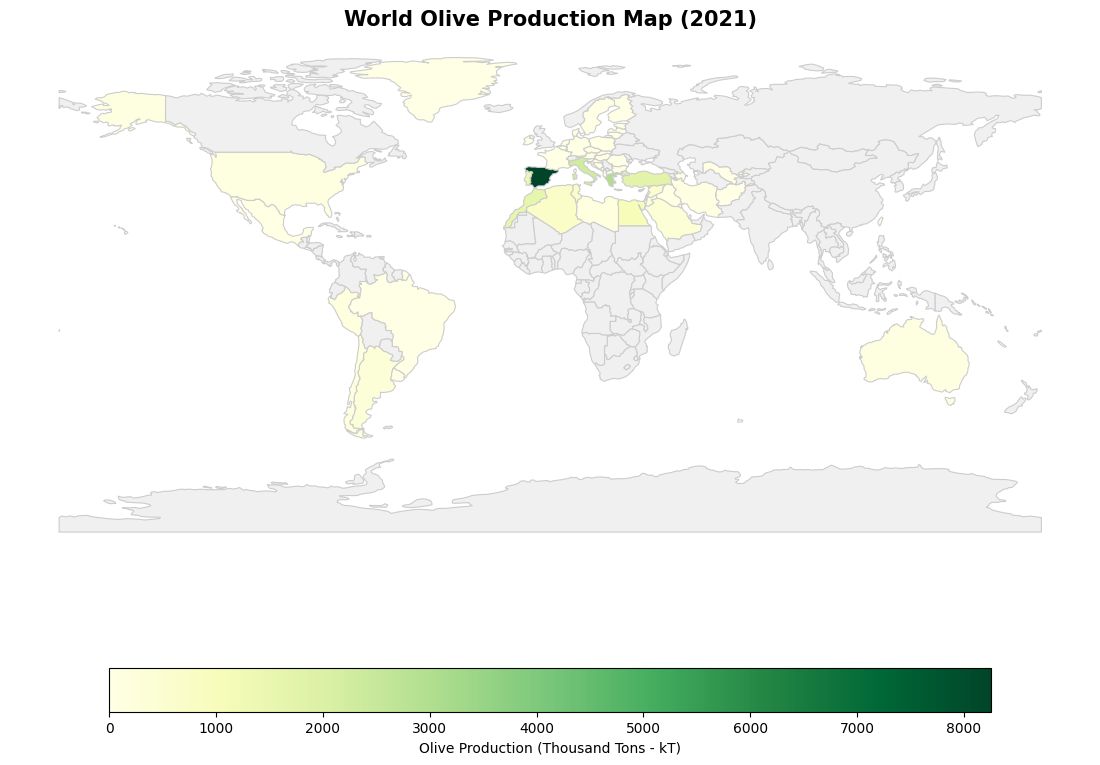

In [24]:
import matplotlib.pyplot as plt

# Replace FAO country names with World Map country names

name_corrections = {
    'China, Taiwan Province of': 'Taiwan',
    'Türkiye': 'Turkey',
    'Iran (Islamic Republic of)': 'Iran',
    'Netherlands (Kingdom of the)': 'Netherlands',
    'Syrian Arab Republic': 'Syria' 
}

df_map_data['Area'] = df_map_data['Area'].replace(name_corrections)


# 3. Merge FAOSTAT data with World Map
world_merged = world.merge(
    df_map_data, 
    left_on='SOVEREIGNT', 
    right_on='Area', 
    how='left'
)

# Map Design
fig, ax = plt.subplots(1, 1, figsize=(15, 8))

world_merged.plot(
    column='Production_kTons',
    cmap='YlGn',             # Green palette for olive
    linewidth=0.8,
    ax=ax,
    edgecolor='0.8',
    legend=True,
    missing_kwds={'color': '#f0f0f0'},
    legend_kwds={
        'label': "Olive Production (Thousand Tons - kT)",
        'orientation': "horizontal",
        'shrink': 0.6
    }
)

plt.title(f'World Olive Production Map ({target_year})', fontsize=15, fontweight='bold')
ax.set_axis_off()

plt.tight_layout()

# Save map
plt.savefig(
    'olives_production_map_2021.png', 
    dpi=300,                           
    bbox_inches='tight',              # Removes white borders around the image
    transparent=False                  
)

plt.show()

#### 💡 Key Findings & Spatial Insights

* **Extreme Geographic Clustering (Mediterranean Core):** 
  * The choropleth map visually confirms that commercial olive production is almost entirely restricted to the **Mediterranean basin** ($30^\circ\text{--}45^\circ\text{ N}$ latitude belt), dictated by Mediterranean climatic conditions (mild, wet winters and long, hot, dry summers).
* **Spain's Massive Outlier Dominance:** 
  * **Spain** stands out as an intense dark-green outlier on the map (>8,000 kT), producing significantly more volume than all non-European countries combined.
* **Secondary Clusters & Secondary Hemispheric Pockets:** 
  * **Southern Europe & North Africa:** A strong secondary cluster spans Greece, Italy, Turkey, Morocco, Tunisia, and Syria.
  * **Southern Hemisphere Adoption:** Minor, light-yellow activity zones are visible in secondary Mediterranean-climate zones, such as central Chile, Argentina, South Australia, and California (USA).

### 25. Comprehensive Spatial Data Diagnostics for Global Maize Analysis
Expanding the spatial scope from localized Mediterranean commodities to a global primary staple like **Maize (corn)** requires a significantly broader entity-matching strategy, as virtually all agricultural nations produce or track maize yields.

**Key Technical Actions:**
* **Target Isolation:** Filtered national records for `Maize (corn)` using the latest year (`2023`) to analyze land productivity (`Yield`).
* **Macro Set Audit:** Executed full-spectrum set operations between `df_countries['Area']` and `world['SOVEREIGNT']` to capture all missing links.

In [25]:
### World Map for Yield of Maize (Corn) ###

import geopandas as gpd
import pandas as pd

# Filterin for Production data (Maize for 2021)
target_item = 'Maize (corn)'
target_year = 2023

df_map_data = df_countries[
    (df_countries['Item'] == target_item) & 
    (df_countries['Year'] == target_year)
][['Area', 'Yield']].dropna().copy()


area_countries = set(df_countries['Area'].dropna().unique())
sovereignt_countries = set(world['SOVEREIGNT'].dropna().unique())

print("\n\n=== In 'df_countries' Not In 'world' ===")
print(sorted(area_countries - sovereignt_countries))

print("\n\n=== In 'world' Not In 'df_countries' ===")
print(sorted(sovereignt_countries - area_countries))



=== In 'df_countries' Not In 'world' ===
['Antigua and Barbuda', 'Bahamas', 'Bahrain', 'Barbados', 'Belgium-Luxembourg', 'Bolivia (Plurinational State of)', 'Brunei Darussalam', 'Cabo Verde', 'China, Hong Kong SAR', 'China, Macao SAR', 'China, Taiwan Province of', 'China, mainland', 'Comoros', 'Congo', 'Cook Islands', 'Czechoslovakia', "Côte d'Ivoire", "Democratic People's Republic of Korea", 'Dominica', 'Eswatini', 'Ethiopia PDR', 'Faroe Islands', 'French Guiana', 'French Polynesia', 'Grenada', 'Guadeloupe', 'Iran (Islamic Republic of)', 'Kiribati', "Lao People's Democratic Republic", 'Maldives', 'Malta', 'Marshall Islands', 'Martinique', 'Mauritius', 'Micronesia (Federated States of)', 'Nauru', 'Netherlands (Kingdom of the)', 'New Caledonia', 'Niue', 'Palestine', 'Puerto Rico', 'Republic of Korea', 'Republic of Moldova', 'Russian Federation', 'Réunion', 'Saint Kitts and Nevis', 'Saint Lucia', 'Saint Vincent and the Grenadines', 'Samoa', 'Sao Tome and Principe', 'Serbia', 'Serbia an

#### 💡 Key Findings & Extended Name Alignment Mapping

* **Scale of Discrepancies:** Because maize is ubiquitous, the set comparison revealed **27 core sovereign mismatches** alongside non-sovereign micro-islands and historical state aggregates (e.g., *'USSR'*, *'Czechoslovakia'*).
* **Categories of Structural Divergence:**
  * **Formal State Titles vs. GIS Conventions:** FAO's *'Russian Federation'*, *'Bolivarian Republic of Venezuela'*, and *'Plurinational State of Bolivia'* mapped to *'Russia'*, *'Venezuela'*, and *'Bolivia'*.
  * **Divided Regions & Asian Nomenclature:** *'China, mainland'* mapped to *'China'*, alongside standardized designations for *'North Korea'*, *'South Korea'*, *'Vietnam'*, and *'Laos'*.
  * **African & European Naming Updates:** Alignment of *'Côte d'Ivoire'* (*'Ivory Coast'*), *'Eswatini'* (*'eSwatini'*), and *'Serbia'* (*'Republic of Serbia'*).

* **Expanded Mapping Dictionary (`name_corrections`):**
  To achieve near-100% global spatial coverage for the upcoming choropleth map, the expanded dictionary comprehensively bridges FAOSTAT data with Natural Earth geometries:
  ```python
  name_corrections = {
      'China, Taiwan Province of': 'Taiwan',
      'Türkiye': 'Turkey',
      'Iran (Islamic Republic of)': 'Iran',
      'Netherlands (Kingdom of the)': 'Netherlands',
      'Syrian Arab Republic': 'Syria',
      'Bahamas': 'The Bahamas',
      'Bolivia (Plurinational State of)': 'Bolivia',
      'Brunei Darussalam': 'Brunei',
      'China, mainland': 'China',
      'Timor-Leste': 'East Timor',
      "Côte d'Ivoire": 'Ivory Coast',
      'Republic of Moldova': 'Moldova',
      "Democratic People's Republic of Korea": 'North Korea',
      'Republic of Korea': 'South Korea',
      'Serbia': 'Republic of Serbia',
      'Congo': 'Republic of the Congo',
      "Lao People's Democratic Republic": 'Laos',
      'Russian Federation': 'Russia',
      'United Kingdom of Great Britain and Northern Ireland': 'United Kingdom',
      'Venezuela (Bolivarian Republic of)': 'Venezuela',
      'Viet Nam': 'Vietnam',
      'Eswatini': 'eSwatini'
  }

### 26. Global Spatial Mapping of Maize Yield Efficiency (2023)
Having expanded our geographic lookup dictionary, we merge the complete `2023` maize dataset with spatial polygons to map land productivity efficiency (`Yield` in `kg/ha`) on a global scale.

**Key Technical Actions:**
* **Complete Entity Alignment:** Applied the 22-item `name_corrections` dictionary to eliminate spatial matching gaps across major producing nations.
* **Choropleth Rendering:** Visualized land yield intensity using an orange sequential color palette (`Oranges`) and exported the resulting map (`maize_production_map_2023.png`).

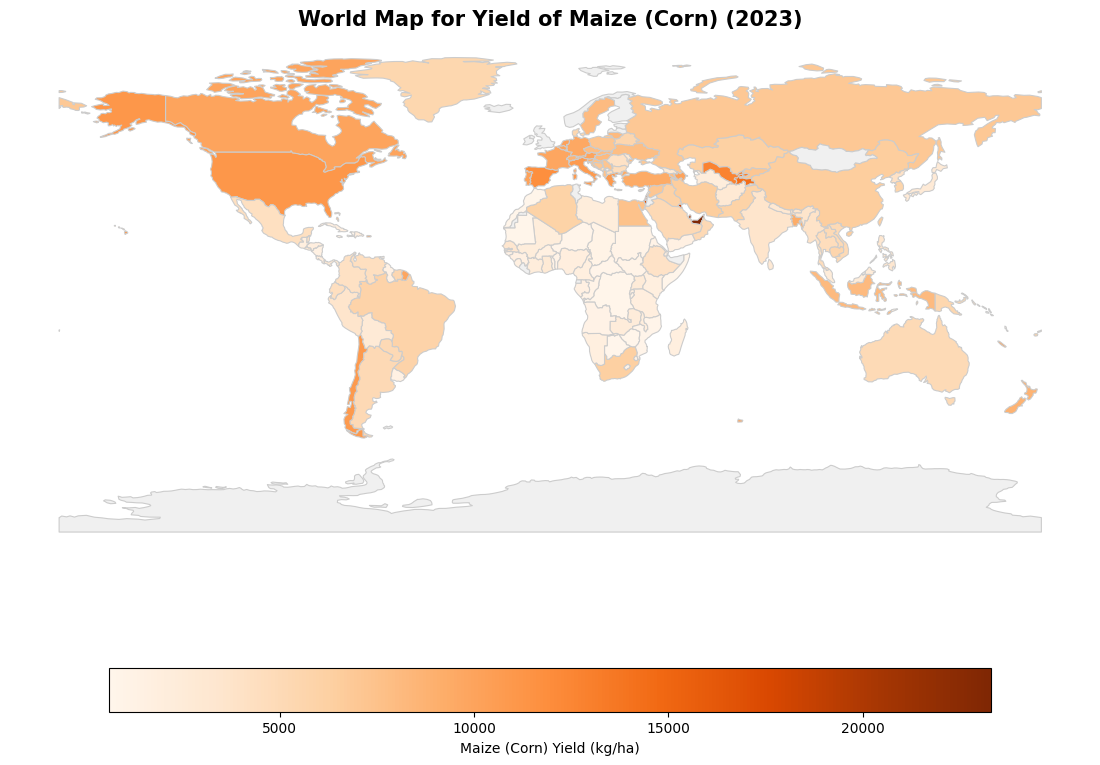

In [26]:
import matplotlib.pyplot as plt

# Replace FAO country names with World Map country names

name_corrections = {
    'China, Taiwan Province of': 'Taiwan',
    'Türkiye': 'Turkey',
    'Iran (Islamic Republic of)': 'Iran',
    'Netherlands (Kingdom of the)': 'Netherlands',
    'Syrian Arab Republic': 'Syria',
    'Bahamas': 'The Bahamas',
    'Bolivia (Plurinational State of)': 'Bolivia',
    'Brunei Darussalam': 'Brunei',
    'China, mainland': 'China',
    'Timor-Leste': 'East Timor',
    'Côte d\'Ivoire': 'Ivory Coast',
    'Republic of Moldova': 'Moldova',
    'Democratic People\'s Republic of Korea': 'North Korea',
    'Republic of Korea': 'South Korea',
    'Serbia': 'Republic of Serbia',
    'Congo': 'Republic of the Congo',
    'Lao People\'s Democratic Republic': 'Laos',
    'Russian Federation': 'Russia',
    'United Kingdom of Great Britain and Northern Ireland': 'United Kingdom',
    'Venezuela (Bolivarian Republic of)': 'Venezuela',
    'Viet Nam': 'Vietnam',
    'Eswatini': 'eSwatini'
}

df_map_data['Area'] = df_map_data['Area'].replace(name_corrections)


# 3. Merge FAOSTAT data with World Map
world_merged = world.merge(
    df_map_data, 
    left_on='SOVEREIGNT', 
    right_on='Area', 
    how='left'
)

# Map Design
fig, ax = plt.subplots(1, 1, figsize=(15, 8))

world_merged.plot(
    column='Yield',
    cmap='Oranges',
    linewidth=0.8,
    ax=ax,
    edgecolor='0.8',
    legend=True,
    missing_kwds={'color': '#f0f0f0'},
    legend_kwds={
        'label': "Maize (Corn) Yield (kg/ha)",
        'orientation': "horizontal",
        'shrink': 0.6
    }
)

plt.title(f'World Map for Yield of Maize (Corn) ({target_year})', fontsize=15, fontweight='bold')
ax.set_axis_off()

plt.tight_layout()

# Save map
plt.savefig(
    'maize_production_map_2023.png', 
    dpi=300,                           
    bbox_inches='tight',              # Removes white borders around the image
    transparent=False                  
)

plt.show()

#### 💡 Key Findings & Global Spatial Insights

* **Widespread Global Cultivation:** 
  Unlike olives, maize coverage spans nearly all continents, illustrating its vital role in global food security, livestock feed, and industrial processing.

* **Yield Concentration Hotspots (Dark Orange Belts):** 
  * **North America:** The **United States** stands out with high yield intensity across its Corn Belt, driven by high-tech mechanization, hybrid seed varieties, and optimized fertilization.
  * **Western & Southern Europe:** Strong productivity hubs emerge across Western Europe (e.g., France, Spain) and the Mediterranean/Balkan regions (including Greece and Turkey), where intensive irrigation maximizes land efficiency.
  * **Central Asia & Middle East (Irrigated & High-Tech Outliers):** 
    * A prominent dark spot in Central Asia highlights Tajikistan, which achieves remarkable per-hectare maize yields through heavily irrigated river valleys and intensive production systems.
    * Similarly, small localized hotspots in the Persian Gulf (e.g., UAE) reflect hyper-intensive, controlled-environment farming systems yielding high output on limited land.

* **Extensive Farming & Development Gaps (Lighter Shades):** 
  * Large regions across Sub-Saharan Africa, parts of Latin America, and South Asia display lighter shading, reflecting lower per-hectare yields due to rainfed reliance, smaller farm scales, and limited access to modern agronomic inputs.

### 27. Machine Learning Feature Engineering for Country-Level Agricultural Clustering
To transition from descriptive statistics to unsupervised machine learning, we prepare a nation-level feature matrix for `2021` aimed at categorizing countries based on their structural agricultural profiles rather than raw geographic size alone.

**Key Technical Actions:**
* **Data Cleaning & Filtering:** Filtered valid records with non-zero harvested area and yield values across 199 unique national entities.
* **Feature Construction:** Engineered three core multi-dimensional agricultural indicators per country:
  1. **`Total_Area_ha`:** Total harvested land capacity ($ha$).
  2. **`Mean_Yield`:** Average land productivity across all cultivated crops ($kg/ha$).
  3. **`Crop_Diversity`:** Count of unique agricultural products harvested (`nunique`), representing crop portfolio diversification.
* **Feature Scaling:** Applied `StandardScaler` to transform features into zero-mean, unit-variance vectors ($Z$-scores) to prevent high-magnitude area metrics from dominating distance-based algorithms.

In [27]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Select target year
target_year = 2021

# Filtering target year and products with no null values
df_ml_raw = df_countries[
    (df_countries['Year'] == target_year) & 
    (df_countries['Area harvested'] > 0) & 
    (df_countries['Yield'] > 0)
].copy()

# Three Aggregations per Country
df_features = df_ml_raw.groupby('Area').agg(
    Total_Area_ha=('Area harvested', 'sum'),
    Mean_Yield=('Yield', 'mean'),
    Crop_Diversity=('Item', 'nunique')
).reset_index()

# Normalization (StandardScaler)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_features[['Total_Area_ha', 'Mean_Yield', 'Crop_Diversity']])

print(f"✅ Feature Matrix has been created for {len(df_features)} coubtries.")
print(df_features.head())

✅ Feature Matrix has been created for 199 coubtries.
                  Area  Total_Area_ha  Mean_Yield  Crop_Diversity
0          Afghanistan     6468654.00     6452.70              48
1              Albania      589477.00    18420.43              69
2              Algeria     7082164.00    12053.97              69
3               Angola    12475058.00     7998.88              46
4  Antigua and Barbuda        6098.00     3626.82              34


#### 💡 Key Findings & Feature Matrix Structure

* **Dataset Scale:** Successfully processed and aggregated data across **199 countries**, creating a balanced baseline for spatial machine learning.
* **Feature Archetypes:** 
  * The dataset captures distinct structural variations, such as countries with massive land cultivation, high-productivity intensive agriculture and high crop diversification.

### 28. Unsupervised Machine Learning: K-Means Clustering & PCA Dimensionality Reduction
To group global agricultural economies into meaningful profiles, we execute **K-Means Clustering** ($K=3$) on our scaled 3D feature matrix (`Total_Area_ha`, `Mean_Yield`, `Crop_Diversity`). To visualize these multi-dimensional clusters on a 2D plane, we apply **Principal Component Analysis (PCA)**.

**Key Technical Actions:**
* **Model Training:** Trained K-Means ($K=3$, `random_state=42`) to segment 199 countries into distinct agricultural profiles.
* **Dimensionality Reduction:** Reduced the 3D feature space to two Principal Components (PC1 and PC2) while capturing **79.6% of total dataset variance** ($46.4\%$ via PC1 and $33.2\%$ via PC2).
* **Scatter Plot Visualization:** Mapped country spatial distribution across PC axes and highlighted representative nations.

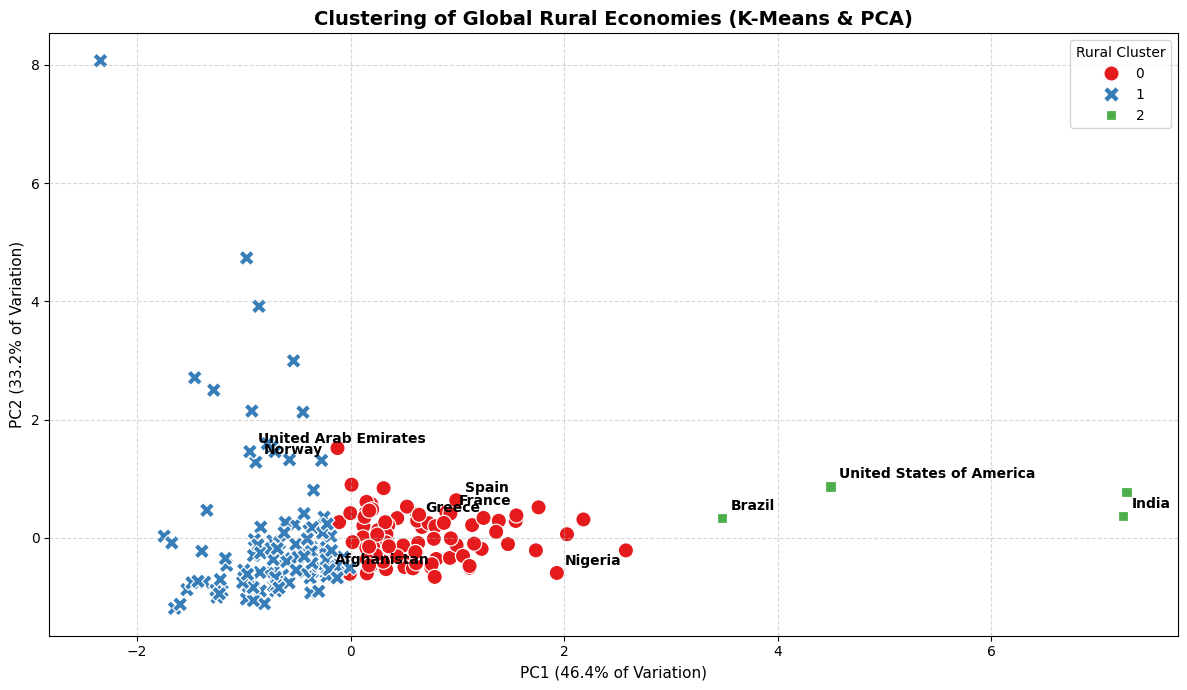

In [28]:
# Training K-Means with 3 Clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_features['Cluster'] = kmeans.fit_predict(X_scaled)

# Applying PCA to reduce to 2 components (PC1, PC2)
pca = PCA(n_components=2)
pca_coords = pca.fit_transform(X_scaled)

df_features['PC1'] = pca_coords[:, 0]
df_features['PC2'] = pca_coords[:, 1]

# Designing Scatter Plot of Clusters
plt.figure(figsize=(12, 7))

ax = sns.scatterplot(
    data=df_features,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='Set1',
    s=120,
    style='Cluster'
)

# Labels for characteristic countries
highlight_countries = ['Greece', 'Spain', 'Nigeria', 'Norway', 'United Arab Emirates', 'Afghanistan', 'United States of America', 'China', 'Brazil', 'India', 'France']

for _, row in df_features.iterrows():
    if row['Area'] in highlight_countries:
        ax.annotate(
            row['Area'],
            (row['PC1'], row['PC2']),
            xytext=(6, 6),
            textcoords='offset points',
            fontsize=10,
            fontweight='bold'
        )

plt.title('Clustering of Global Rural Economies (K-Means & PCA)', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% of Variation)', fontsize=11)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% of Variation)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Rural Cluster', fontsize=10)

plt.tight_layout()
plt.show()

#### 💡 Key Geometric & Dimensionality Insights

* **Dimensionality Compression Efficiency:** 
  The 2D PCA projection captures **79.6% of total dataset variance**, proving that two synthetic dimensions are fully sufficient to separate global rural economies without losing critical structural information.

* **PC Axes Interpretation:**
  * **Horizontal Axis (PC1 - 46.4% Variance):** Captures overall agricultural scale and diversity. Countries shift rightward as land area and crop variety increase.
  * **Vertical Axis (PC2 - 33.2% Variance):** Captures yield anomalies and specialized land productivity. Extreme top outliers (e.g., UAE) seems to represent nations with localized, ultra-high yield efficiency.

* **Spatial Separation:** 
  The graph demonstrates clear boundary separation between the dense core of smaller/medium economies on the left, high-diversity intensive producers in the center, and the isolated global superpowers positioned far to the right.

### 29. Statistical Aggregation of Cluster Profiles
With each nation assigned to a cluster via K-Means, we compute group-level mean statistics for `Total_Area_ha`, `Mean_Yield`, and `Crop_Diversity` to quantitatively analyze the structural differences between clusters.

**Key Technical Actions:**
* **Cluster Aggregation:** Computed country counts and group mean averages across arable land size, yield, and crop diversity.
* **Unit Standardization:** Converted raw hectare averages into **Million Hectares (Mha)** (`Mean_Area_Mha`) for cleaner quantitative comparison.

In [29]:
# Calculation of average prices and number of countries per Cluster
cluster_profile = df_features.groupby('Cluster').agg(
    Count=('Area', 'count'),
    Mean_Area_ha=('Total_Area_ha', 'mean'),
    Mean_Yield=('Mean_Yield', 'mean'),
    Mean_Diversity=('Crop_Diversity', 'mean')
).reset_index()

# Convert to Million Hectares (Mha)
cluster_profile['Mean_Area_Mha'] = cluster_profile['Mean_Area_ha'] / 1_000_000

print("📊 Rural Clusters Profile (2021):")
print(cluster_profile[['Cluster', 'Count', 'Mean_Area_Mha', 'Mean_Yield', 'Mean_Diversity']])

📊 Rural Clusters Profile (2021):
   Cluster  Count  Mean_Area_Mha  Mean_Yield  Mean_Diversity
0        0     86          18.95    11703.52           73.74
1        1    109           2.42    13230.94           35.36
2        2      4         331.63    13359.96           98.50


#### 💡 Key Quantitative Findings & Strategic Policy Takeaways

* **⚡ The Yield Convergence Paradox:** 
  Average yields (`Mean_Yield`) are nearly identical across all three groups (**~11,700 to 13,350 kg/ha**). Global rural differentiation is **not driven by productivity per hectare**, but by **land scale (Area)** and **crop diversification (Diversity)**.

#### 📊 Quantitative Cluster Profiles

* **🔴 Cluster 0 (European & Intensive Diversified | 86 Countries | Greece, Spain, France):** 
  * **Metrics:** **18.95 Mha** mean area, **~74 unique crops**, **11,703 kg/ha** mean yield.
  * **Role:** High-value quality orientation (PDO/PGI) and strong crop portfolio risk dispersion.

* **🔵 Cluster 1 (Small-Scale or Specialized | 109 Countries | UAE, Norway, Afghanistan):** 
  * **Metrics:** **2.42 Mha** mean area, **~35 unique crops**, **13,230 kg/ha** mean yield.
  * **Role:** Territorial/climatic land constraints; elevated exposure to supply chain shocks due to low crop diversity.

* **🟢 Cluster 2 (Global Superpowers | 4 Countries | USA, China, India, Brazil):** 
  * **Metrics:** **331.63 Mha** mean area, **~98 unique crops**, **13,359 kg/ha** mean yield.
  * **Role:** Bulk commodity market dominance through sheer land scale and modern industrial logistics.

#### 🎯 Strategic Storytelling Conclusion
Because global yields have converged, countries like **Greece (Cluster 0)** cannot compete on volume against Cluster 2 superpowers. Policy must double down on quality differentiation, green transition, and specialized branding rather than raw production scale.

### 30. Spatial Choropleth Mapping of Unsupervised Agricultural Clusters
To ground our machine learning results in real-world geography, we merge the K-Means cluster assignments (`Cluster 0, 1, 2`) with spatial boundaries to visualize how global rural profiles align across continents.

**Key Technical Actions:**
* **Name Standardisation:** Re-applied `name_corrections` to `df_features['Area']` to bridge country identifiers with the Natural Earth spatial shapefile.
* **Categorical Mapping:** Rendered a discrete choropleth map using a custom color ramp (`Red` = Cluster 0, `Blue` = Cluster 1, `Green` = Cluster 2).

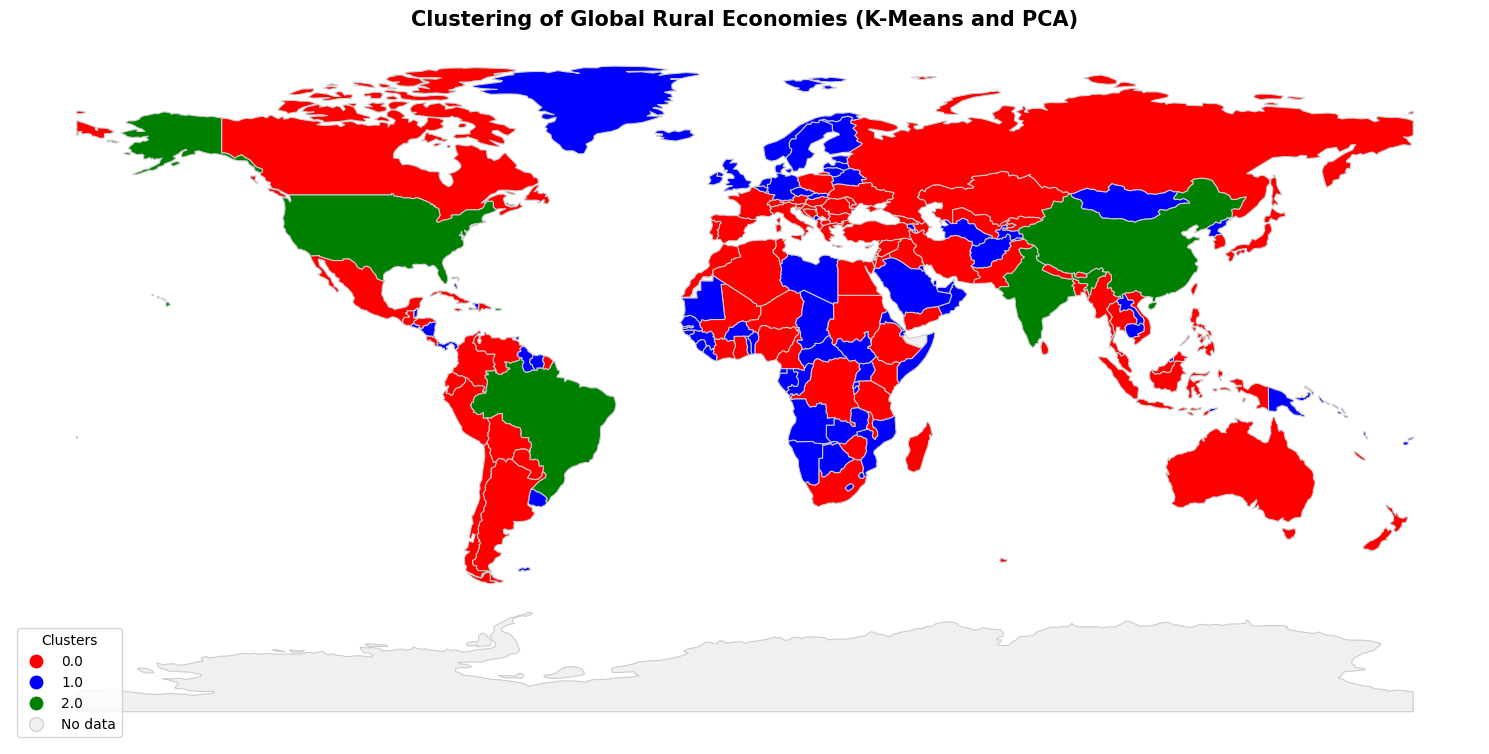

In [30]:
from matplotlib.colors import ListedColormap

df_features['Area'] = df_features['Area'].replace(name_corrections)


# Merge FAOSTAT data with World Map
world_merged = world.merge(
    df_features, 
    left_on='SOVEREIGNT', 
    right_on='Area', 
    how='left'
)


cmap_custom = ListedColormap(['red', 'blue', 'green'])

# Map Design
fig, ax = plt.subplots(1, 1, figsize=(15, 8))

world_merged.plot(
    column='Cluster',
    categorical=True,              
    cmap=cmap_custom,               
    linewidth=0.8,
    ax=ax,
    edgecolor='0.8',
    legend=True,
    legend_kwds={'title': 'Clusters', 'loc': 'lower left'},
    missing_kwds={'color': '#f0f0f0', 'label': 'No data'}
)

plt.title('Clustering of Global Rural Economies (K-Means and PCA)', fontsize=15, fontweight='bold')
ax.set_axis_off()

plt.tight_layout()

              

plt.show()

#### 💡 Key Spatial Findings & Geoclimatic Insights

* **The Geographic vs. Arable Land Paradox:**
  The map reveals a stark contrast between a nation's **total geographic footprint** and its actual **harvested agricultural area**:
  * **Nordic & Polar Regions (Canada, Scandinavia):** Despite massive sovereign landmasses, countries like Canada, Norway, Sweden, and Finland map to **Cluster 1 (Blue)**. Extremely cold climates, short growing seasons, and tundra/boreal forests drastically restrict arable land.
  * **Desert & Arid Zones (Algeria, Libya, Saudi Arabia, Australia):** Vast geographic expanses covered primarily by hyper-arid deserts limit arable cultivation, placing them in **Cluster 1 (Blue)** or specialized subgroups.

* **Macro Cluster Distribution:**
  * **🟢 Cluster 2 (Global Superpowers - Green):** USA, Brazil, India, and China form contiguous land-rich agricultural blocks with vast plains and high output capacity.
  * **🔴 Cluster 0 (Intensive & Diversified - Red):** Covers Southern and Central Europe (including Greece), parts of Latin America, and Australia—representing specialized, high-diversity agricultural hubs.
  * **🔵 Cluster 1 (Constrained / Specialized - Blue):** Encompasses mountainous, polar, or desert-dominated sovereign states with limited total arable capacity.

* **⚠️ Analytical Transition Note (Scale Skewness):**
  Spatial visualization confirms that **absolute land scale dominates Euclidean distance calculations in K-Means**, pushing multi-million hectare outliers (USA, China, India, Brazil) into an isolated cluster. To mitigate this extreme variance and evaluate productivity on a balanced scale, our next step applies a **Logarithmic Transformation (`np.log1p`)** to harvested land areas.

### 31. Feature Engineering Optimization: Logarithmic Transformation (`np.log1p`)
To address the overwhelming dominance of absolute land scale in Euclidean distance metrics, we apply a logarithmic transformation to the harvested area variable. This mathematical adjustment compresses extreme upper-tail outliers while preserving ordinal relationships across global economies.

**Key Technical Actions:**
* **Pipeline Cleanup:** Dropped temporary 2D projection vectors (`PC1`, `PC2`) and previous discrete assignments (`Cluster`).
* **Log-Scaling Transformation:** Applied `np.log1p()` ($\ln(1 + x)$) to `Total_Area_ha` to create `Total_Area_log`, smoothing high-skew distributions across multi-million hectare outliers.
* **Feature Matrix Re-Standardization:** Executed `StandardScaler` on the newly balanced feature set (`Total_Area_log`, `Mean_Yield`, `Crop_Diversity`) to build $X_{scaled\_lg}$.

In [31]:
df_features = df_features.drop(columns=['PC1','PC2','Cluster'], errors='ignore')

# Convert Total Area to logarithm logarithm of area 
# to compress the difference between small and large countries.
df_features['Total_Area_log'] = np.log1p(df_features['Total_Area_ha'])

# Normalization (StandardScaler)
scaler = StandardScaler()
X_scaled_lg = scaler.fit_transform(df_features[['Total_Area_log', 'Mean_Yield', 'Crop_Diversity']])

print(f"✅ Feature Matrix has been created for {len(df_features)} countries.")
print(df_features.head())



✅ Feature Matrix has been created for 199 countries.
                  Area  Total_Area_ha  Mean_Yield  Crop_Diversity  \
0          Afghanistan     6468654.00     6452.70              48   
1              Albania      589477.00    18420.43              69   
2              Algeria     7082164.00    12053.97              69   
3               Angola    12475058.00     7998.88              46   
4  Antigua and Barbuda        6098.00     3626.82              34   

   Total_Area_log  
0           15.68  
1           13.29  
2           15.77  
3           16.34  
4            8.72  


#### 💡 Key Technical Findings & Mathematical Impact

* **Variance Compression:** 
  The transformation drastically narrows the numerical gap between micro-producers and agrarian superpowers. For instance, the raw area ratio between **Antigua and Barbuda** ($6,098\text{ ha}$) and **Angola** ($12.47\text{M ha}$) drops from a raw $\sim2,045\times$ scale factor to a normalized logarithmic ratio of just $\sim1.87\times$ ($8.72$ vs. $16.34$).

* **Balanced Clustering Input:** 
  By dampening extreme area variance, distance-based algorithms like K-Means can now evaluate **crop diversity** and **yield intensity** on an equal footing with physical scale.

* **Next Step:** We will re-run the K-Means clustering algorithm and PCA projection on $X_{scaled\_lg}$ to uncover nuanced, efficiency-driven global rural groupings.

### 32. Re-clustering & PCA Visualization with Log-Transformed Features
To evaluate the true multidimensional structure of global agriculture without scale dominance, we fit a new K-Means model ($K=3$) on the scaled logarithmic feature matrix ($X_{scaled\_lg}$) and project the data onto a 2D PCA coordinate space.

**Key Technical Actions:**
* **Model Re-fitting:** Re-executed K-Means ($K=3$) on log-transformed variables (`Total_Area_log`, `Mean_Yield`, `Crop_Diversity`).
* **2D Projection Mapping:** Computed Principal Components (PC1 & PC2), retaining **79.6% of overall variance** ($46.4\%$ via PC1 and $33.2\%$ via PC2).
* **Scatter Plot Visualization:** Plotted country spatial distributions using `sns.scatterplot()` with annotated target nations for clear group boundary inspection.

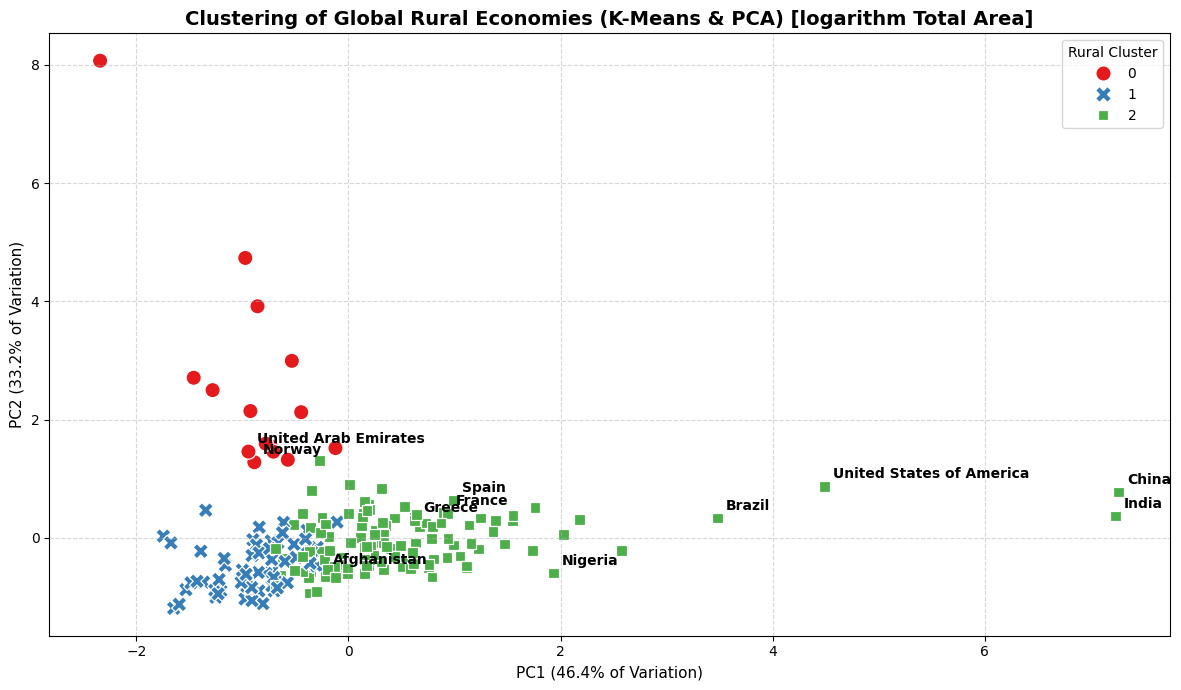

In [32]:
df_features['Cluster'] = kmeans.fit_predict(X_scaled_lg)

df_features['PC1'] = pca_coords[:, 0]
df_features['PC2'] = pca_coords[:, 1]

# Designing Scatter Plot of Clusters
plt.figure(figsize=(12, 7))

ax = sns.scatterplot(
    data=df_features,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='Set1',
    s=120,
    style='Cluster'
)

for _, row in df_features.iterrows():
    if row['Area'] in highlight_countries:
        ax.annotate(
            row['Area'],
            (row['PC1'], row['PC2']),
            xytext=(6, 6),
            textcoords='offset points',
            fontsize=10,
            fontweight='bold'
        )

plt.title('Clustering of Global Rural Economies (K-Means & PCA) [logarithm Total Area]', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% of Variation)', fontsize=11)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% of Variation)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Rural Cluster', fontsize=10)

plt.tight_layout()
plt.show()

#### 💡 Key Geometric & Structural Insights (Log Scale)

* **Elimination of Superpower Isolation:** 
  In the raw-scale model, USA, China, India, and Brazil formed an exclusive 4-country cluster due to massive land area. Under the logarithmic transformation, these superpowers now anchor the right edge of **Cluster 2 (Green)**, forming a continuous spectrum with other diversified agrarian economies (e.g., France, Spain, Greece, Nigeria).

* **PC Axes Structural Interpretation:**
  * **Horizontal Axis (PC1 - 46.4% Variance):** Primary measure of **Crop Portfolio Scale & Diversity**. Moves left-to-right from specialized/small economies to highly diversified agricultural systems.
  * **Vertical Axis (PC2 - 33.2% Variance):** Primary measure of **Yield Efficiency Anomalies**. Captures high productivity per land unit, separating intensive/specialized outliers along the upper vertical region.

* **Cluster Structural Roles:**
  * **🟢 Cluster 2 (Green - Diversified Agricultural Producers):** Spans mid-to-high PC1. Unites large agricultural giants with European diversified producers (France, Greece, Spain) that share high crop diversity despite smaller absolute land footprints.
  * **🔵 Cluster 1 (Blue - Limited/Specialized Scale):** Concentrated on low PC1 values. Represents economies with constrained arable capacity or targeted crop options (e.g., Afghanistan).
  * **🔴 Cluster 0 (Red - Intensive Productivity Outliers):** Positioned along high PC2 values (e.g., UAE, Norway). Highlights countries with extreme land constraints using highly specialized or high-tech agricultural practices to achieve disproportionate yield output.

### 33. Statistical Profiling of Log-Transformed Clusters
With the new clustering assignments generated from the log-scaled feature matrix, we compute summary statistics for each group to precisely quantify their differences. 

**Key Technical Actions:**
* **Cluster Aggregation:** Grouped the 199 countries by their new cluster labels (0, 1, and 2).
* **Metric Averaging:** Calculated country counts and aggregated group means across logarithmic land scale (`Total_Area_log`), mean yield (`Mean_Yield`), and crop count (`Mean_Diversity`).

In [33]:
# Calculation of average prices and number of countries per Cluster
cluster_profile = df_features.groupby('Cluster').agg(
    Count=('Area', 'count'),
    Mean_Area_ha=('Total_Area_log', 'mean'),
    Mean_Yield=('Mean_Yield', 'mean'),
    Mean_Diversity=('Crop_Diversity', 'mean')
).reset_index()

print("📊 Rural Clusters Profile (2021) [logarithm Total Area]:")
print(cluster_profile[['Cluster', 'Count', 'Mean_Area_ha', 'Mean_Yield', 'Mean_Diversity']])

📊 Rural Clusters Profile (2021) [logarithm Total Area]:
   Cluster  Count  Mean_Area_ha  Mean_Yield  Mean_Diversity
0        0     15         12.84    42357.28           38.73
1        1     61         10.94     8280.13           29.05
2        2    123         15.77    11070.47           66.97


#### 💡 Key Quantitative Findings & Strategic Policy Takeaways (Log Scale)

* **Elimination of the Yield Convergence Paradox:** 
  Unlike the raw-scale model where yields were nearly identical across clusters, the logarithmic model successfully unlocks yield variance as a key differentiator. The clusters now reveal drastically different productivity profiles, proving the log-transformation successfully recalibrated the model's sensitivity.

#### 📊 Quantitative Cluster Profiles

* **🔴 Cluster 0 (Intensive High-Yield Outliers | 15 Countries | e.g., UAE, Norway):** 
  * **Metrics:** **12.84** mean log area, **~39 unique crops**, **42,357 kg/ha** mean yield.
  * **Role:** A niche group of highly specialized, often land-constrained or climatically challenged nations achieving extraordinary per-hectare productivity.
  * **Policy Direction:** Focus on controlled-environment agriculture, advanced agritech (hydroponics, smart greenhouses), and extreme yield maximization strategies to offset limited physical footprint or hostile climates.

* **🔵 Cluster 1 (Small-Scale & Limited Diversity | 61 Countries | e.g., Afghanistan):** 
  * **Metrics:** **10.94** mean log area, **~29 unique crops**, **8,280 kg/ha** mean yield.
  * **Role:** Smaller economies or nations constrained by geography/development, characterized by the lowest physical scale, lowest productivity, and most limited crop portfolios.
  * **Policy Direction:** Highest vulnerability to supply shocks. Strategy must prioritize systemic development, basic mechanization, yield improvement, and expanding crop portfolios to build basic food security.

* **🟢 Cluster 2 (Diversified Core & Superpowers | 123 Countries | e.g., USA, France, Greece):** 
  * **Metrics:** **15.77** mean log area, **~67 unique crops**, **11,070 kg/ha** mean yield.
  * **Role:** The dominant global agricultural bloc. By compressing extreme scale outliers, this cluster merges absolute giants (USA, China) with mid-sized, highly diversified European/global producers (Greece, Spain, France) that share broad agricultural capabilities.
  * **Policy Direction:** Represents robust, multi-crop agrarian economies prioritizing high diversification for market resilience, standard industrial yields, and large functional land bases.

### 34. Optimized Choropleth Mapping: Spatial Analysis Post Log Transformation
To evaluate how logarithmic scaling re-aligns global agricultural profiles on a geographic level, we re-merge our updated dataset (`Total_Area_log`) with spatial world boundaries and plot the recalibrated clusters.

**Key Technical Actions:**
* **Spatial Merging:** Linked the log-transformed cluster identifiers (`Cluster 0, 1, 2`) with the Natural Earth geometry layer via standard country keys.
* **Map Rendering:** Generated a categorical map using the discrete color scheme (`Red` = Cluster 0, `Blue` = Cluster 1, `Green` = Cluster 2).

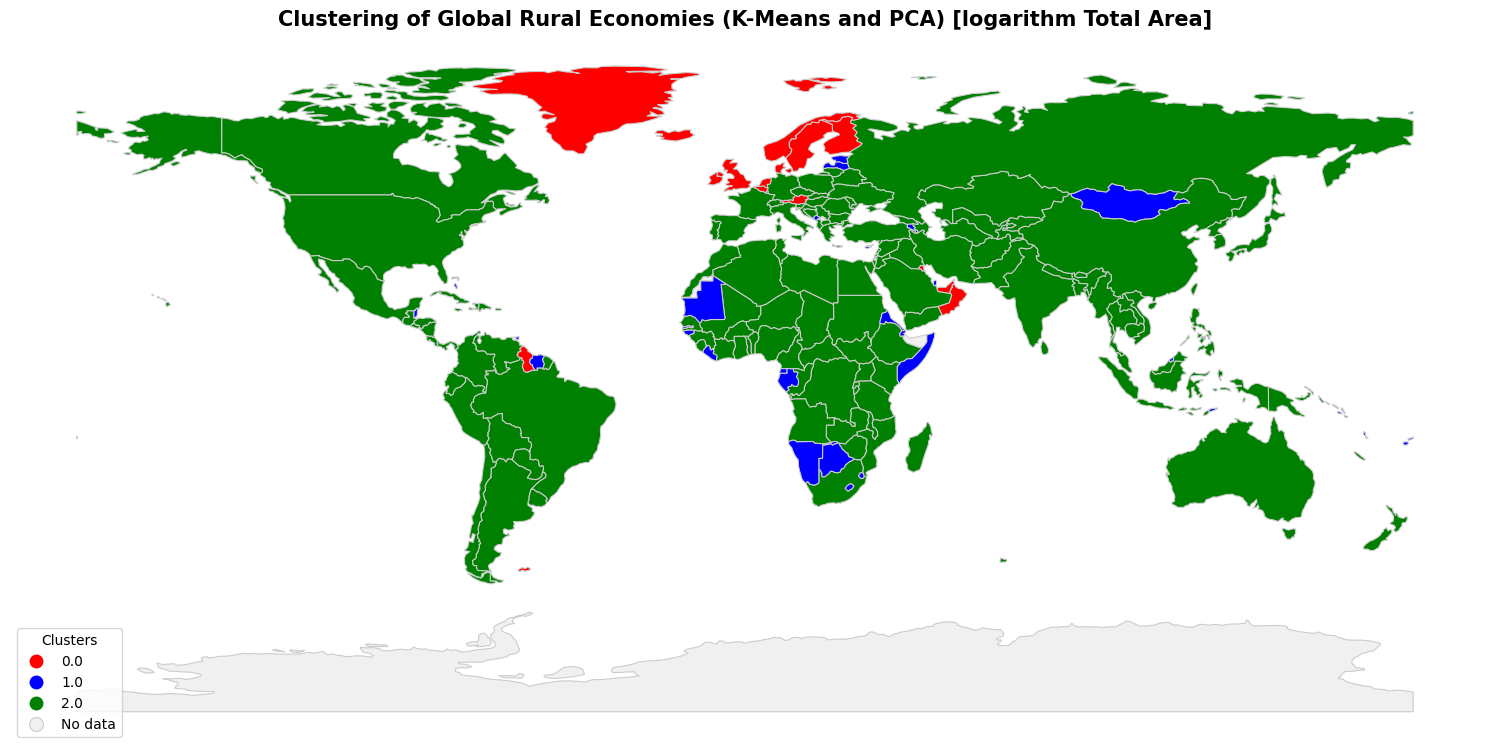

In [34]:
from matplotlib.colors import ListedColormap

df_features['Area'] = df_features['Area'].replace(name_corrections)


# Merge FAOSTAT data with World Map
world_merged = world.merge(
    df_features, 
    left_on='SOVEREIGNT', 
    right_on='Area', 
    how='left'
)


cmap_custom = ListedColormap(['red', 'blue', 'green'])

# Map Design
fig, ax = plt.subplots(1, 1, figsize=(15, 8))

world_merged.plot(
    column='Cluster',
    categorical=True,              
    cmap=cmap_custom,               
    linewidth=0.8,
    ax=ax,
    edgecolor='0.8',
    legend=True,
    legend_kwds={'title': 'Clusters', 'loc': 'lower left'},
    missing_kwds={'color': '#f0f0f0', 'label': 'No data'}
)

plt.title('Clustering of Global Rural Economies (K-Means and PCA) [logarithm Total Area]', fontsize=15, fontweight='bold')
ax.set_axis_off()

plt.tight_layout()

              

plt.show()

#### 💡 Key Spatial Findings & Comparative Insights (Raw vs. Log Map)

* **The Global Agrarian Backbone (🟢 Cluster 2 - Green):** 
  Unlike the initial map where Cluster 2 was restricted to only 4 absolute superpowers, the log-transformed model reveals that the majority of North and South America, Europe, South/East Asia, and major African economies share a fundamental baseline: significant crop diversification ($\sim67\text{ crops}$) and balanced operational land scale.

* **High-Yield Efficiency Outliers (🔴 Cluster 0 - Red):** 
  Re-mapping highlights specific geographical micro-environments. Northern Europe (Norway, Finland, Iceland) and arid, tech-driven economies (UAE) are isolated in red, marking regions where severe land/climatic constraints are counterbalanced by extreme yield maximization and specialized agritech.

* **Structural Vulnerability Belt (🔵 Cluster 1 - Blue):** 
  Concentrated in landlocked, arid, or mountainous sub-regions (e.g., Afghanistan, parts of Sub-Saharan Africa), identifying nations facing dual hurdles of restricted crop portfolios ($\sim29\text{ crops}$) and lower relative productivity.

#### 🎯 Data Science Methodological Takeaway

Comparing the two choropleth visualizations demonstrates how mathematical feature engineering impacts real-world policy interpretations:
1. **Raw Features:** Distance metrics were overwhelmed by extreme land outliers (USA, China), treating all other nations as a uniform secondary group.
2. **Log Features:** Distance metrics evaluated **efficiency and diversification on an equal plane**, successfully revealing true functional peer groups across the global rural economy.

### 35. Comprehensive Project Summary & Final Insights

#### 🎯 Executive Summary & End-to-End Analytical Journey
This project executed a complete, multi-stage Data Science, Geospatial, and Unsupervised Machine Learning pipeline on the UN FAOSTAT agricultural database (1961–2023). Moving from raw data ingestion to policy-level insights, the study unlocked structural patterns in global, regional, and national food systems.

---

#### 📌 Complete Analytical & Methodological Highlights

* **1. Data Engineering & Integrity Assurance (Sections 1–10):**
  * **Dynamic Ingestion & Reshaping:** Integrated local and Colab/Kagglehub pipelines, processing 79,711 raw flagged records across 60+ years (1961–2023) and unpivoting them into a long-format dataset of over **1.73 million records**.
  * **Duplicate Resolution (Egg Metrics):** Removed 613 duplicate records in livestock commodities by standardizing conflicting mass vs. volume units (`1000 No` vs `tonnes`).
  * **Disambiguation & Aggregation Filtering:** Leveraged the FAOSTAT M49 coding convention ($Code \ge 5000$) and resolved the composite **China (Code 351)** exception to isolate 210 standalone countries from 35 macro-regional aggregates, completely eliminating double-counting risks.

* **2. Global & Domestic Production Benchmarks (Sections 11–15):**
  * **Mass vs. Nutrient Output:** **Sugar cane** stands as the largest crop by mass globally (>2.02B tonnes in 2023), while **Maize** leads staple grains (1.24B tonnes).
  * **Hellenic Domestic Baseline:** Greece’s top volume production is anchored by field crops (**Maize** at 1.42M tonnes, **Wheat** at 1.31M tonnes) and Mediterranean specialty commodities (**Sheep Milk** at ~944K tonnes for Feta production, **Oranges**, **Tomatoes**, and **Grapes**).
  * **Yield Hierarchy Paradox:** While cattle lead global per-animal milk output (3,105 kg/An) compared to sheep (77 kg/An), Greece achieves high national sheep milk volumes through intense livestock population density and specialized pastoral systems.

* **3. Spatial Distribution & Historical Policy Impacts (Sections 16–21):**
  * **Spatial Hotspots:** Mapped the absolute concentration of **Olives** in the Mediterranean ($30^\circ\text{--}45^\circ\text{ N}$ belt with Spain as an 8,250 kT outlier) versus the global distribution of **Maize** and **Wheat**.
  * **40-Year Timeline in Greece (1980–2021):** Captured biological **biennial bearing** in olives, the **1993 EEC Vine Grubbing Scheme** (Regulation 1442/88) causing a grape production drop, the post-1981 EEC accession surge in cotton, and the post-2004 CAP subsidy decoupling driving a shift away from low-margin wheat.
  * **Greece vs. EU Benchmark (2021):** Greece shows a **+41% yield premium in Maize (11.20 t/ha vs 7.90 t/ha)** due to solar radiation and intensive plain irrigation, outpaces the EU in Olives (3.70 t/ha vs 3.00 t/ha), but trails in Wheat due to rainfed Mediterranean soil constraints.

* **4. Machine Learning & The Scale Dominance Paradox (Sections 22–34):**
  * **Raw Scale Failure:** Running K-Means on raw area (`Total_Area_ha`) caused Euclidean distance metrics to be dominated by multi-million hectare land outliers (**USA, China, India, Brazil**), pushing them into an isolated 4-country group while grouping the rest of the world uniformly.
  * **Log Transformations (`np.log1p`):** Compressing area variance allowed **crop portfolio diversity** and **yield efficiency** to participate equally in distance metrics ($79.6\%$ variance explained across PC1 & PC2).
  * **Final Clusters:** Uncovered 3 distinct functional groups: **Cluster 2** (123 Diversified Agrarian Core nations including Greece, USA, France), **Cluster 0** (15 High-Yield Agritech Outliers like UAE & Norway at ~42,357 kg/ha), and **Cluster 1** (61 Small/Vulnerable economies like Afghanistan with ~29 crops).

---

#### 💡 Strategic Policy Takeaways

1. **Strategic Positioning for Greece:** With global yields converged and raw volume controlled by superpowers, mid-scale producers like **Greece** cannot compete on raw quantity. National policy must focus on **quality differentiation (PDO/PGI branding)**, **high-yield C4 crop irrigation efficiency**, and **precision agriculture**.
2. **CAP & Economic Resilience:** Multi-decade data proves policy shifts directly alter agricultural landscapes. Maintaining high crop diversity acts as an essential macroeconomic buffer against climate and market volatility.